In [2]:
%pip install -e "/content/drive/MyDrive/BUSI-XAI"

Obtaining file:///content/drive/MyDrive/BUSI-XAI
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for busi-xai (pyproject.toml) ... done
  Created wheel for busi-xai: filename=busi_xai-0.1.0-0.editable-py3-none-any.whl size=1176 sha256=99df68d070a66661f9f1569db9f2f7abc5bd781ab51bd799f265e55c323827ee
  Stored in directory: /tmp/pip-ephem-wheel-cache-nvi17ops/wheels/bc/96/6a/14ad5b6a03036f6f181aa62fbcb8d63ac3b6cb1da04fcdcb1e
Successfully built busi-xai


In [ ]:
%pip install grad-cam
%pip install lime
%pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=9d93306a2d352372e9f3a6bc9e1ffed8443b77db48946289097f89d7ab4945dd
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=f9f2f1203570dcbd65cc697eada3e9c4b68c5ffd35e8b7c1f4e5adb163ddc2bc
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


# Check previous stages

In [ ]:
from pathlib import Path
import json
import pandas as pd

from busi_xai.config import (
    MODELS_DIR,
    METRICS_DIR,
)

from busi_xai.data import (
    BUSIDataset,
    build_image_transform,
    transform_mask,
)

from busi_xai.model import (
    build_resnet50,
    load_checkpoint,
    evaluate_model,
)

print("=== Project paths ===")
print("Models:", MODELS_DIR)
print("Metrics:", METRICS_DIR)

checkpoint_path = MODELS_DIR / "resnet50_best.pt"
metrics_path = METRICS_DIR / "test_classification_metrics.json"
history_path = METRICS_DIR / "training_history.csv"

print("\n=== Artifact existence ===")
print("Checkpoint:", checkpoint_path.exists(), checkpoint_path)
print("Metrics:", metrics_path.exists(), metrics_path)
print("History:", history_path.exists(), history_path)

assert checkpoint_path.exists(), "Best model checkpoint is missing."
assert metrics_path.exists(), "Final classification metrics artifact is missing."
assert history_path.exists(), "Training history artifact is missing."

print("\n=== Classification metrics ===")

with open(metrics_path, "r") as f:
    metrics = json.load(f)

print(json.dumps(metrics, indent=2))

print("\n=== Training history ===")

history = pd.read_csv(history_path)

print("History rows:", len(history))
print("History columns:", history.columns.tolist())

assert len(history) == 20, "Training history must contain exactly 20 rows."

best_row = history.loc[history["validation_loss"].idxmin()]

print("\nBest epoch from history:", int(best_row["epoch"]))
print("Best validation loss:", float(best_row["validation_loss"]))

assert int(best_row["epoch"]) == 8
assert abs(
    float(best_row["validation_loss"]) - 0.314631738436988
) < 1e-9

print("\n=== Package imports ===")
print("BUSIDataset:", BUSIDataset)
print("build_image_transform:", build_image_transform)
print("transform_mask:", transform_mask)
print("build_resnet50:", build_resnet50)
print("load_checkpoint:", load_checkpoint)
print("evaluate_model:", evaluate_model)

=== Project paths ===
Models: /content/drive/MyDrive/BUSI-XAI/outputs/models
Metrics: /content/drive/MyDrive/BUSI-XAI/outputs/metrics

=== Artifact existence ===
Checkpoint: True /content/drive/MyDrive/BUSI-XAI/outputs/models/resnet50_best.pt
Metrics: True /content/drive/MyDrive/BUSI-XAI/outputs/metrics/test_classification_metrics.json
History: True /content/drive/MyDrive/BUSI-XAI/outputs/metrics/training_history.csv

=== Classification metrics ===
{
  "model": "ResNet-50",
  "dataset": "BUSI",
  "test_samples": 97,
  "checkpoint_epoch": 8,
  "validation_loss_at_checkpoint": 0.314631738436988,
  "accuracy": 0.8969072164948454,
  "precision_malignant": 0.8387096774193549,
  "recall_malignant": 0.8387096774193549,
  "f1_malignant": 0.8387096774193549,
  "specificity_benign": 0.9242424242424242,
  "confusion_matrix": {
    "true_negative": 61,
    "false_positive": 5,
    "false_negative": 5,
    "true_positive": 26
  },
  "classification_report": {
    "benign": {
      "precision": 0.92

# Generate XAI protocol

In [ ]:
import json
from pathlib import Path

from busi_xai.config import (
    XAI_RANDOM_SEED,
    XAI_EVALUATION_SPLIT,
    XAI_NUM_TEST_SAMPLES,
    XAI_IMAGE_SIZE,
    XAI_MAP_DTYPE,
    XAI_MAP_MIN,
    XAI_MAP_MAX,
    XAI_TARGET,
    XAI_MASK_RESIZE_INTERPOLATION,
    XAI_MASK_BINARY,
    XAI_METHODS,
    XAI_RECORD_RUNTIME,
    XAI_OUTPUT_DIR,
)


protocol = {
    "experiment": "BUSI-XAI",
    "evaluation_split": XAI_EVALUATION_SPLIT,
    "num_test_samples": XAI_NUM_TEST_SAMPLES,
    "xai_methods": list(XAI_METHODS),
    "target": XAI_TARGET,
    "image_size": list(XAI_IMAGE_SIZE),
    "common_map": {
        "dtype": XAI_MAP_DTYPE,
        "minimum": XAI_MAP_MIN,
        "maximum": XAI_MAP_MAX,
        "non_negative": True,
    },
    "ground_truth_masks": {
        "resize_interpolation": XAI_MASK_RESIZE_INTERPOLATION,
        "binary": XAI_MASK_BINARY,
    },
    "random_seed": XAI_RANDOM_SEED,
    "record_runtime": XAI_RECORD_RUNTIME,
    "model_selection": "validation_loss_only",
    "test_set_used_for_model_selection": False,
    "model_retraining_for_xai": False,
}

protocol_path = XAI_OUTPUT_DIR / "xai_protocol.json"
protocol_path.parent.mkdir(parents=True, exist_ok=True)

with protocol_path.open("w") as f:
    json.dump(protocol, f, indent=2)

print(f"Protocol saved to: {protocol_path}")

Protocol saved to: /content/drive/MyDrive/BUSI-XAI/outputs/xai/xai_protocol.json


# Test get gradcam target layer

In [ ]:
from busi_xai.config import XAI_IMAGE_SIZE
from busi_xai.model import build_resnet50
from busi_xai.xai import (
    normalize_attribution_map,
    get_resnet50_gradcam_target_layer,
    generate_gradcam,
)

model = build_resnet50(num_classes=2)

target_layer = get_resnet50_gradcam_target_layer(model)

print("Target layer:", target_layer)
print("Expected image size:", XAI_IMAGE_SIZE)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


Target layer: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)
Expected image size: (224, 224)


# Test freeze model

In [ ]:
import torch

from busi_xai.config import MODELS_DIR
from busi_xai.model import build_resnet50, load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_resnet50(num_classes=2)

checkpoint_path = MODELS_DIR / "resnet50_best.pt"

checkpoint = load_checkpoint(
    model=model,
    checkpoint_path=checkpoint_path,
    device=device,
)

model = model.to(device)
model.eval()

# Freeze model parameters for XAI.
for parameter in model.parameters():
    parameter.requires_grad = True

print("Device:", device)
print("Checkpoint:", checkpoint_path)
print("Loaded checkpoint epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["validation_loss"])
print(
    "All parameters frozen:",
    all(not p.requires_grad for p in model.parameters()),
)

Device: cpu
Checkpoint: /content/drive/MyDrive/BUSI-XAI/outputs/models/resnet50_best.pt
Loaded checkpoint epoch: 8
Validation loss: 0.314631738436988
All parameters frozen: False


# Explain single prediction

In [ ]:
import pandas as pd
import torch
from busi_xai.data import BUSIDataset, build_image_transform
from busi_xai.xai import explain_single_prediction
from busi_xai.config import SPLITS_DIR,MODELS_DIR
from busi_xai import model
from busi_xai.model import build_resnet50, load_checkpoint
import numpy as np


# Load the existing test split.
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

test_dataset = BUSIDataset(
    dataframe=test_df,
    image_column="processed_image",
    class_column="class_name",
    image_transform=build_image_transform(train=False),
    mask_column="processed_mask",
)

sample_index = 0
sample = test_dataset[sample_index]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_resnet50(num_classes=2)

checkpoint_path = MODELS_DIR / "resnet50_best.pt"

checkpoint = load_checkpoint(
    model=model,
    checkpoint_path=checkpoint_path,
    device=device,
)

model = model.to(device)
result = explain_single_prediction(
    model=model,
    image=sample["image"],
    true_label=int(sample["label"].item()),
    image_id=test_df.iloc[sample_index]["image_id"],
    device=device,
)

print("Image ID:", result["image_id"])
print("True label:", result["true_label"])
print("Predicted class:", result["predicted_label"])
print("Predicted probability:", result["predicted_probability"])
print("Correct:", result["correct"])
print("Method:", result["method"])
print("Attribution shape:", result["attribution_map"].shape)
print("Attribution dtype:", result["attribution_map"].dtype)
print("Attribution min:", float(result["attribution_map"].min()))
print("Attribution max:", float(result["attribution_map"].max()))
print("Runtime (seconds):", result["runtime_seconds"])

Image ID: benign (189)
True label: 0
Predicted class: 0
Predicted probability: 0.9900121092796326
Correct: True
Method: gradcam
Attribution shape: (224, 224)
Attribution dtype: float32
Attribution min: 0.0
Attribution max: 1.0
Runtime (seconds): 2.5916584429996874


# Save attribution map

In [ ]:
from busi_xai.config import GRADCAM_OUTPUT_DIR
from busi_xai.xai import save_attribution_map

gradcam_path = GRADCAM_OUTPUT_DIR / f"{result['image_id']}.npy"

saved_path = save_attribution_map(
    attribution_map=result["attribution_map"],
    output_path=gradcam_path,
)

print("Saved Grad-CAM map:", saved_path)

Saved Grad-CAM map: /content/drive/MyDrive/BUSI-XAI/outputs/xai/gradcam/benign (189).npy


In [ ]:
loaded_map = np.load(saved_path)

assert loaded_map.shape == (224, 224)
assert loaded_map.dtype == np.float32
assert np.isfinite(loaded_map).all()
assert float(loaded_map.min()) >= 0.0
assert float(loaded_map.max()) <= 1.0

print("Saved Grad-CAM artifact validation passed.")
print("Shape:", loaded_map.shape)
print("Dtype:", loaded_map.dtype)
print("Range:", float(loaded_map.min()), "to", float(loaded_map.max()))

Saved Grad-CAM artifact validation passed.
Shape: (224, 224)
Dtype: float32
Range: 0.0 to 1.0


# Overlay


Overlay shape: (224, 224, 3)
Overlay dtype: uint8
Overlay range: 1 to 240
Grad-CAM overlay validation passed.


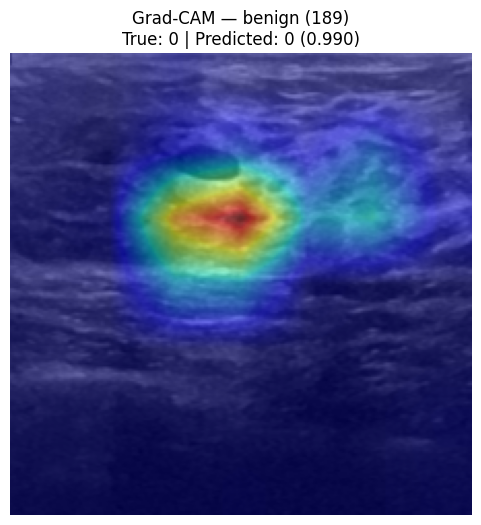

In [ ]:
from busi_xai.xai import create_xai_overlay
import matplotlib.pyplot as plt
overlay = create_xai_overlay(
    image=sample["image"],
    attribution_map=result["attribution_map"],
)

print("Overlay shape:", overlay.shape)
print("Overlay dtype:", overlay.dtype)
print(
    "Overlay range:",
    overlay.min(),
    "to",
    overlay.max(),
)

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.axis("off")
plt.title(
    f"Grad-CAM — {result['image_id']}\n"
    f"True: {result['true_label']} | "
    f"Predicted: {result['predicted_label']} "
    f"({result['predicted_probability']:.3f})"
)
plt.show()

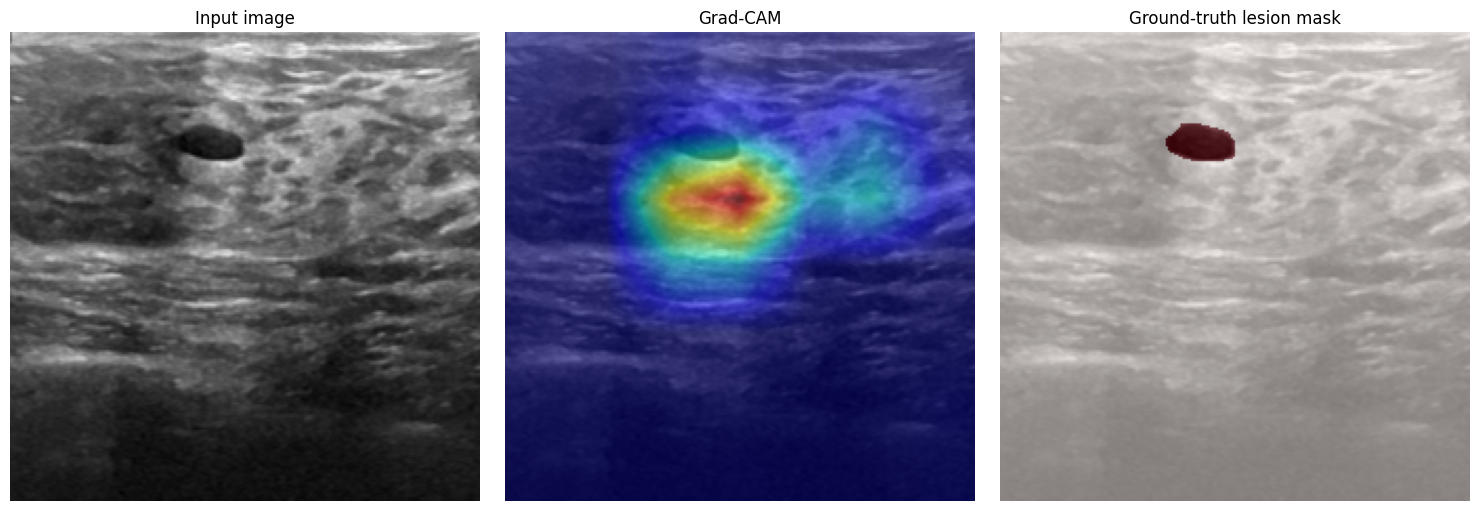

In [ ]:
import matplotlib.pyplot as plt

image = sample["image"].detach().cpu().numpy()

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

image = image.transpose(1, 2, 0)
image = np.clip(image * std + mean, 0.0, 1.0)

ground_truth_mask = sample["mask"].detach().cpu().numpy()

if ground_truth_mask.ndim == 3:
    ground_truth_mask = ground_truth_mask.squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

axes[2].imshow(image)
axes[2].imshow(
    ground_truth_mask,
    alpha=0.5,
    cmap="Reds",
)
axes[2].set_title("Ground-truth lesion mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Binary Mask

In [ ]:
from busi_xai.xai import attribution_to_binary_mask

binary_gradcam = attribution_to_binary_mask(
    attribution_map=result["attribution_map"],
    threshold=0.5,
)

print("Binary mask shape:", binary_gradcam.shape)
print("Binary mask dtype:", binary_gradcam.dtype)
print("Unique values:", np.unique(binary_gradcam))
print("Positive pixels:", int(binary_gradcam.sum()))

Binary mask shape: (224, 224)
Binary mask dtype: uint8
Unique values: [0 1]
Positive pixels: 2003


# IOU & Dice

In [ ]:
from busi_xai.xai import calculate_iou, calculate_dice

ground_truth_mask = (
    sample["mask"]
    .detach()
    .cpu()
    .numpy()
)

if ground_truth_mask.ndim == 3:
    ground_truth_mask = ground_truth_mask.squeeze(0)

ground_truth_mask = (
    ground_truth_mask > 0
).astype(np.uint8)

iou = calculate_iou(
    explanation_mask=binary_gradcam,
    ground_truth_mask=ground_truth_mask,
)

dice = calculate_dice(
    explanation_mask=binary_gradcam,
    ground_truth_mask=ground_truth_mask,
)

print("IoU:", iou)
print("Dice:", dice)

NameError: name 'binary_gradcam' is not defined

In [ ]:
intersection = np.logical_and(
    binary_gradcam.astype(bool),
    ground_truth_mask.astype(bool),
).sum()

explanation_pixels = binary_gradcam.sum()
ground_truth_pixels = ground_truth_mask.sum()
union = np.logical_or(
    binary_gradcam.astype(bool),
    ground_truth_mask.astype(bool),
).sum()

print("Explanation pixels:", int(explanation_pixels))
print("Ground-truth pixels:", int(ground_truth_pixels))
print("Intersection pixels:", int(intersection))
print("Union pixels:", int(union))
print("IoU:", iou)
print("Dice:", dice)
print("Ground-truth mask shape:", ground_truth_mask.shape)
print("Ground-truth unique values:", np.unique(ground_truth_mask))
print(
    "Ground-truth bounding box pixels:",
    np.argwhere(ground_truth_mask).min(axis=0),
    "to",
    np.argwhere(ground_truth_mask).max(axis=0),
)

print(
    "Grad-CAM bounding box pixels:",
    np.argwhere(binary_gradcam).min(axis=0),
    "to",
    np.argwhere(binary_gradcam).max(axis=0),
)

# Debugging low metrics

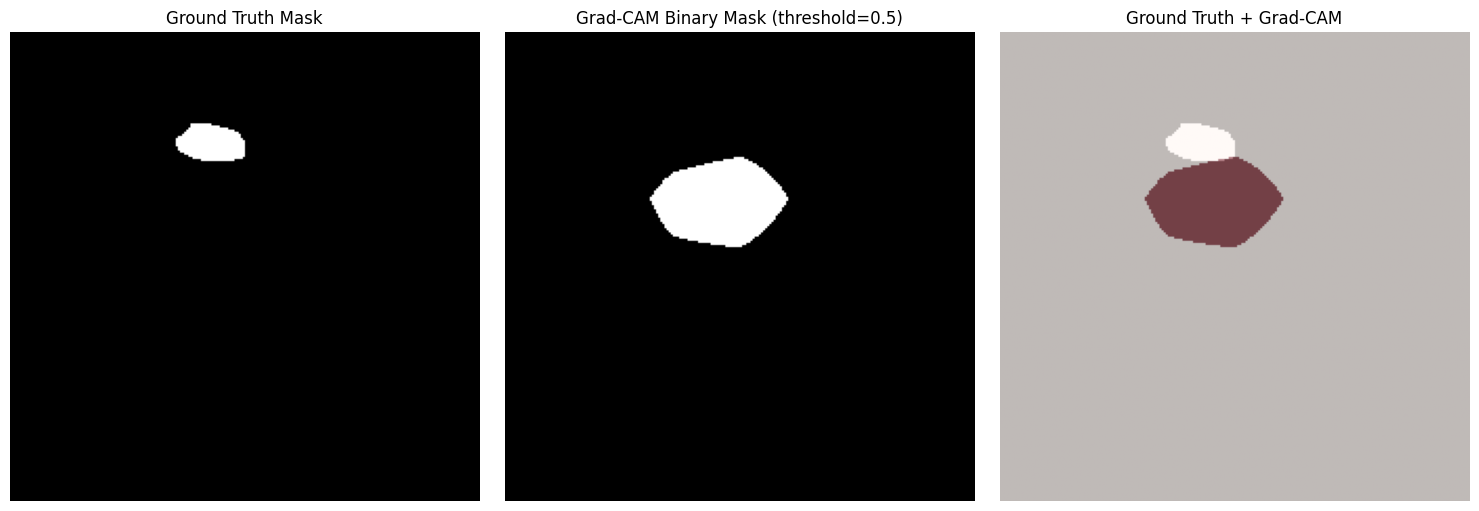

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ground_truth_mask, cmap="gray")
axes[0].set_title("Ground Truth Mask")
axes[0].axis("off")

axes[1].imshow(binary_gradcam, cmap="gray")
axes[1].set_title("Grad-CAM Binary Mask (threshold=0.5)")
axes[1].axis("off")

axes[2].imshow(ground_truth_mask, cmap="gray", alpha=0.5)
axes[2].imshow(binary_gradcam, cmap="Reds", alpha=0.5)
axes[2].set_title("Ground Truth + Grad-CAM")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
attribution = result["attribution_map"]
print("Grad-CAM attribution shape:", attribution.shape)
print("Grad-CAM attribution dtype:", attribution.dtype)
print("Grad-CAM min:", float(attribution.min()))
print("Grad-CAM max:", float(attribution.max()))

print("Pixels >= 0.1:", int((attribution >= 0.1).sum()))
print("Pixels >= 0.25:", int((attribution >= 0.25).sum()))
print("Pixels >= 0.5:", int((attribution >= 0.5).sum()))
print("Pixels >= 0.75:", int((attribution >= 0.75).sum()))
print("Pixels == 1.0:", int((attribution == 1.0).sum()))

Grad-CAM attribution shape: (224, 224)
Grad-CAM attribution dtype: float32
Grad-CAM min: 0.0
Grad-CAM max: 1.0
Pixels >= 0.1: 11533
Pixels >= 0.25: 5688
Pixels >= 0.5: 2003
Pixels >= 0.75: 543
Pixels == 1.0: 1


In [ ]:
import numpy as np

gt = ground_truth_mask.astype(bool)
gc = attribution

# Ground-truth geometry
gt_rows, gt_cols = np.where(gt)

print("Ground-truth positive pixels:", int(gt.sum()))
print("Ground-truth row range:", int(gt_rows.min()), "to", int(gt_rows.max()))
print("Ground-truth column range:", int(gt_cols.min()), "to", int(gt_cols.max()))

print("\nGround-truth row positive-pixel distribution:")
print(
    "min:", int(np.bincount(gt_rows).min()),
    "max:", int(np.bincount(gt_rows).max()),
    "mean:", float(np.bincount(gt_rows).mean()),
)

print("\nGround-truth column positive-pixel distribution:")
print(
    "min:", int(np.bincount(gt_cols).min()),
    "max:", int(np.bincount(gt_cols).max()),
    "mean:", float(np.bincount(gt_cols).mean()),
)

# Grad-CAM high-attribution regions at several percentiles
for percentile in [90, 95, 99]:
    threshold = np.percentile(gc, percentile)
    binary = gc >= threshold

    rows, cols = np.where(binary)

    intersection = np.logical_and(binary, gt).sum()

    print(f"\nGrad-CAM top {100 - percentile:.0f}%:")
    print("Threshold:", float(threshold))
    print("Pixels:", int(binary.sum()))
    print(
        "Bounding box:",
        [int(rows.min()), int(cols.min())],
        "to",
        [int(rows.max()), int(cols.max())],
    )
    print("Intersection with GT:", int(intersection))

Ground-truth positive pixels: 472
Ground-truth row range: 44 to 61
Ground-truth column range: 79 to 111

Ground-truth row positive-pixel distribution:
min: 0 max: 33 mean: 7.612903225806452

Ground-truth column positive-pixel distribution:
min: 0 max: 18 mean: 4.214285714285714

Grad-CAM top 10%:
Threshold: 0.27369779348373413
Pixels: 5018
Bounding box: [51, 59] to [115, 186]
Intersection with GT: 245

Grad-CAM top 5%:
Threshold: 0.43716415762901306
Pixels: 2509
Bounding box: [58, 66] to [105, 137]
Intersection with GT: 50

Grad-CAM top 1%:
Threshold: 0.7598754167556763
Pixels: 502
Bounding box: [70, 83] to [90, 122]
Intersection with GT: 0


In [ ]:
import numpy as np

# Controlled synthetic masks at the experiment's required size
mask_a = np.zeros((224, 224), dtype=np.uint8)
mask_b = np.zeros((224, 224), dtype=np.uint8)

# A: 20x20 square
mask_a[50:70, 50:70] = 1

# B: same 20x20 square shifted right by 10 pixels
mask_b[50:70, 60:80] = 1

expected_intersection = 20 * 10
expected_union = (20 * 20) + (20 * 20) - expected_intersection

expected_iou = expected_intersection / expected_union
expected_dice = (
    2 * expected_intersection
) / (
    mask_a.sum() + mask_b.sum()
)

actual_iou = calculate_iou(mask_a, mask_b)
actual_dice = calculate_dice(mask_a, mask_b)

print("Expected intersection:", expected_intersection)
print("Expected union:", expected_union)
print("Expected IoU:", expected_iou)
print("Expected Dice:", expected_dice)

print("\nActual IoU:", actual_iou)
print("Actual Dice:", actual_dice)

assert np.isclose(actual_iou, expected_iou)
assert np.isclose(actual_dice, expected_dice)

print("\nSynthetic IoU/Dice validation PASSED.")

Expected intersection: 200
Expected union: 600
Expected IoU: 0.3333333333333333
Expected Dice: 0.5

Actual IoU: 0.3333333333333333
Actual Dice: 0.5

Synthetic IoU/Dice validation PASSED.


# Try percentile binary mapping

In [ ]:
from busi_xai.xai import  attribution_to_top_percentile_mask

attribution = result["attribution_map"]
top10_mask = attribution_to_top_percentile_mask(
    attribution,
    percentile=90.0,
)

print("Mask shape:", top10_mask.shape)
print("Mask dtype:", top10_mask.dtype)
print("Unique values:", np.unique(top10_mask))
print("Positive pixels:", int(top10_mask.sum()))
print(
    "Positive-pixel percentage:",
    float(top10_mask.mean() * 100),
)

Mask shape: (224, 224)
Mask dtype: uint8
Unique values: [0 1]
Positive pixels: 5018
Positive-pixel percentage: 10.00079719387755


In [ ]:
from busi_xai.xai import calculate_iou, calculate_dice

# Apply the frozen common localisation rule to the existing Grad-CAM map.
gradcam_top10_mask = attribution_to_top_percentile_mask(
    attribution,
    percentile=90.0,
)

gradcam_top10_iou = calculate_iou(
    gradcam_top10_mask,
    ground_truth_mask,
)

gradcam_top10_dice = calculate_dice(
    gradcam_top10_mask,
    ground_truth_mask,
)

intersection = np.logical_and(
    gradcam_top10_mask.astype(bool),
    ground_truth_mask.astype(bool),
).sum()

union = np.logical_or(
    gradcam_top10_mask.astype(bool),
    ground_truth_mask.astype(bool),
).sum()

print("Top-10% Grad-CAM pixels:", int(gradcam_top10_mask.sum()))
print("Ground-truth pixels:", int(ground_truth_mask.sum()))
print("Intersection:", int(intersection))
print("Union:", int(union))
print("IoU:", gradcam_top10_iou)
print("Dice:", gradcam_top10_dice)

NameError: name 'ground_truth_mask' is not defined

# Lime implementation

In [ ]:
import torch
from pathlib import Path
from busi_xai.config import XAI_RANDOM_SEED

image_tensor = sample["image"].unsqueeze(0).to(device)
true_label = int(sample["label"])

with torch.no_grad():
    logits = model(image_tensor)
    probabilities = torch.softmax(logits, dim=1)

predicted_class = int(torch.argmax(probabilities, dim=1).item())
predicted_probability = float(
    probabilities[0, predicted_class].item()
)

image_id = sample["index"]

print("Image ID:", image_id)
print("Dataset index:", sample_index)
print("True label:", true_label)
print("Predicted class:", predicted_class)
print("Predicted probability:", predicted_probability)
print("Image tensor shape:", tuple(image_tensor.shape))
print("Device:", device)

Image ID: 0
Dataset index: 0
True label: 0
Predicted class: 0
Predicted probability: 0.990011990070343
Image tensor shape: (1, 3, 224, 224)
Device: cuda


In [ ]:
import time
from busi_xai.xai import generate_lime

start_time = time.perf_counter()

lime_attribution = generate_lime(
    model=model,
    image_tensor=image_tensor,
    device=device,
    target_class=predicted_class,
    random_seed=XAI_RANDOM_SEED,
    num_samples=1000,
)

lime_runtime = time.perf_counter() - start_time

print("LIME attribution shape:", lime_attribution.shape)
print("LIME attribution dtype:", lime_attribution.dtype)
print("LIME attribution min:", float(lime_attribution.min()))
print("LIME attribution max:", float(lime_attribution.max()))
print("LIME runtime:", lime_runtime)

  0%|          | 0/1000 [00:00<?, ?it/s]

LIME attribution shape: (224, 224)
LIME attribution dtype: float32
LIME attribution min: 0.0
LIME attribution max: 1.0
LIME runtime: 9.683179865000056


In [ ]:
from busi_xai.xai import  attribution_to_top_percentile_mask
from busi_xai.xai import calculate_iou, calculate_dice

ground_truth_mask = (
    sample["mask"]
    .detach()
    .cpu()
    .numpy()
)

if ground_truth_mask.ndim == 3:
    ground_truth_mask = ground_truth_mask.squeeze(0)

ground_truth_mask = (
    ground_truth_mask > 0
).astype(np.uint8)


lime_top10_mask = attribution_to_top_percentile_mask(
    lime_attribution,
    percentile=90.0,
)

lime_iou = calculate_iou(
    lime_top10_mask,
    ground_truth_mask,
)

lime_dice = calculate_dice(
    lime_top10_mask,
    ground_truth_mask,
)

intersection = np.logical_and(
    lime_top10_mask.astype(bool),
    ground_truth_mask.astype(bool),
).sum()

union = np.logical_or(
    lime_top10_mask.astype(bool),
    ground_truth_mask.astype(bool),
).sum()

print("LIME top-10% pixels:", int(lime_top10_mask.sum()))
print("Ground-truth pixels:", int(ground_truth_mask.sum()))
print("Intersection:", int(intersection))
print("Union:", int(union))
print("IoU:", lime_iou)
print("Dice:", lime_dice)

LIME top-10% pixels: 5174
Ground-truth pixels: 472
Intersection: 100
Union: 5546
IoU: 0.018031013342949875
Dice: 0.035423308537017355


# Shap implementation

In [ ]:
import time
from busi_xai.xai import generate_shap


start_time = time.perf_counter()

shap_attribution = generate_shap(
    model=model,
    image_tensor=image_tensor,
    device=device,
    target_class=predicted_class,
    random_seed=XAI_RANDOM_SEED,
    num_samples=100,
)

shap_runtime = time.perf_counter() - start_time

print("SHAP attribution shape:", shap_attribution.shape)
print("SHAP attribution dtype:", shap_attribution.dtype)
print("SHAP attribution min:", float(shap_attribution.min()))
print("SHAP attribution max:", float(shap_attribution.max()))
print("SHAP runtime:", shap_runtime)

SHAP attribution shape: (224, 224)
SHAP attribution dtype: float32
SHAP attribution min: 0.0
SHAP attribution max: 1.0
SHAP runtime: 1.988757410999824


In [ ]:
shap_binary_mask = attribution_to_top_percentile_mask(
    shap_attribution,
    percentile=90.0,
)

shap_iou = calculate_iou(
    shap_binary_mask,
    ground_truth_mask,
)

shap_dice = calculate_dice(
    shap_binary_mask,
    ground_truth_mask,
)

print("SHAP explanation pixels:", int(shap_binary_mask.sum()))
print("Ground-truth pixels:", int(ground_truth_mask.sum()))
print("Intersection:", int((shap_binary_mask & ground_truth_mask).sum()))
print("Union:", int((shap_binary_mask | ground_truth_mask).sum()))
print("SHAP IoU:", shap_iou)
print("SHAP Dice:", shap_dice)

SHAP explanation pixels: 5018
Ground-truth pixels: 472
Intersection: 377
Union: 5113
SHAP IoU: 0.0737336201838451
SHAP Dice: 0.13734061930783242


# Test XAI record

In [ ]:
from busi_xai.xai import build_xai_record

shap_record = build_xai_record(
    image_id=0,
    dataset_index=0,
    true_label=int(sample["label"]),
    predicted_class=predicted_class,
    predicted_probability=predicted_probability,
    method="shap",
    runtime=shap_runtime,
    attribution=shap_attribution,
    ground_truth_mask=ground_truth_mask,
    localisation_percentile=90.0,
)

print(shap_record)

{'image_id': 0, 'dataset_index': 0, 'true_label': 0, 'predicted_class': 0, 'predicted_probability': 0.990011990070343, 'correct': True, 'method': 'shap', 'runtime_seconds': 1.988757410999824, 'localisation_percentile': 90.0, 'explanation_pixels': 5018, 'ground_truth_pixels': 472, 'intersection_pixels': 377, 'union_pixels': 5113, 'iou': 0.0737336201838451, 'dice': 0.13734061930783242}


In [ ]:
print("=== Test loader ===")
print("test_loader type:", type(test_dataset))
print("test_loader batches:", len(test_dataset))

# Inspect one test batch
test_batch = next(iter(test_dataset))

print("\n=== Test batch ===")
print("Type:", type(test_batch))

if isinstance(test_batch, dict):
    print("Keys:", test_batch.keys())

    for key, value in test_batch.items():
        if hasattr(value, "shape"):
            print(f"{key}: shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"{key}: type={type(value)}")

else:
    print("Batch length:", len(test_batch))

    for i, value in enumerate(test_batch):
        if hasattr(value, "shape"):
            print(f"[{i}]: shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"[{i}]: type={type(value)}")

=== Test loader ===
test_loader type: <class 'busi_xai.data.BUSIDataset'>
test_loader batches: 97

=== Test batch ===
Type: <class 'dict'>
Keys: dict_keys(['image', 'label', 'index', 'mask'])
image: shape=torch.Size([3, 224, 224]), dtype=torch.float32
label: shape=torch.Size([]), dtype=torch.int64
index: type=<class 'int'>
mask: shape=torch.Size([1, 224, 224]), dtype=torch.float32


In [ ]:
print("\n=== Test dataset ===")
print("Dataset type:", type(test_dataset))
print("Dataset length:", len(test_dataset))

sample = test_dataset[0]

print("\n=== First dataset sample ===")
print("Type:", type(sample))

if isinstance(sample, dict):
    print("Keys:", sample.keys())

    for key, value in sample.items():
        if hasattr(value, "shape"):
            print(f"{key}: shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"{key}: type={type(value)}, value={value}")
else:
    print(sample)


=== Test dataset ===
Dataset type: <class 'busi_xai.data.BUSIDataset'>
Dataset length: 97

=== First dataset sample ===
Type: <class 'dict'>
Keys: dict_keys(['image', 'label', 'index', 'mask'])
image: shape=torch.Size([3, 224, 224]), dtype=torch.float32
label: shape=torch.Size([]), dtype=torch.int64
index: type=<class 'int'>, value=0
mask: shape=torch.Size([1, 224, 224]), dtype=torch.float32


# Test evaluate XAI methods

In [ ]:
from busi_xai.xai import evaluate_xai_methods

test_records, test_attributions = evaluate_xai_methods(
    model=model,
    dataset=test_dataset,
    device=device,
    methods=("gradcam", "lime", "shap"),
    random_seed=42,
    lime_num_samples=1000,
    shap_num_samples=100,
    localisation_percentile=90.0,
    max_samples=2,
)

print("\nRecords:", len(test_records))
print("Attribution maps:", len(test_attributions))

for record in test_records:
    print(record)

[1/2] index=0, true=0, pred=0


  0%|          | 0/1000 [00:00<?, ?it/s]

[2/2] index=1, true=0, pred=0


  0%|          | 0/1000 [00:00<?, ?it/s]


Records: 6
Attribution maps: 6
{'image_id': 0, 'dataset_index': 0, 'true_label': 0, 'predicted_class': 0, 'predicted_probability': 0.990011990070343, 'correct': True, 'method': 'gradcam', 'runtime_seconds': 0.024983329999940906, 'localisation_percentile': 90.0, 'explanation_pixels': 5018, 'ground_truth_pixels': 472, 'intersection_pixels': 245, 'union_pixels': 5245, 'iou': 0.04671115347950429, 'dice': 0.08925318761384335}
{'image_id': 0, 'dataset_index': 0, 'true_label': 0, 'predicted_class': 0, 'predicted_probability': 0.990011990070343, 'correct': True, 'method': 'lime', 'runtime_seconds': 9.438077631999931, 'localisation_percentile': 90.0, 'explanation_pixels': 5174, 'ground_truth_pixels': 472, 'intersection_pixels': 100, 'union_pixels': 5546, 'iou': 0.018031013342949875, 'dice': 0.035423308537017355}
{'image_id': 0, 'dataset_index': 0, 'true_label': 0, 'predicted_class': 0, 'predicted_probability': 0.990011990070343, 'correct': True, 'method': 'shap', 'runtime_seconds': 2.238559797

# Run 3 XAI methods for all test dataset

In [ ]:
from pathlib import Path
from busi_xai.xai import evaluate_xai_methods
from busi_xai.config import XAI_OUTPUT_DIR

records, attribution_maps = evaluate_xai_methods(
    model=model,
    dataset=test_dataset,
    device=device,
    methods=("gradcam", "lime", "shap"),
    random_seed=42,
    lime_num_samples=1000,
    shap_num_samples=100,
    localisation_percentile=90.0,
    max_samples=None,
    output_dir=XAI_OUTPUT_DIR,
)

print("\n=== Full XAI evaluation completed ===")
print("Records:", len(records))
print("Attribution maps:", len(attribution_maps))

[1/97] index=0, true=0, pred=0


  0%|          | 0/1000 [00:00<?, ?it/s]

[2/97] index=1, true=0, pred=0


  0%|          | 0/1000 [00:00<?, ?it/s]

[3/97] index=2, true=0, pred=0


...

[96/97] index=95, true=0, pred=0


  0%|          | 0/1000 [00:00<?, ?it/s]

[97/97] index=96, true=0, pred=0


  0%|          | 0/1000 [00:00<?, ?it/s]


=== Full XAI evaluation completed ===
Records: 291
Attribution maps: 291


# Save evaluation outputs

In [ ]:
from pathlib import Path
from busi_xai.xai import save_xai_evaluation_outputs

records_path = save_xai_evaluation_outputs(
    records=records,
    attribution_maps=attribution_maps,
    output_dir=XAI_OUTPUT_DIR,
)

print("Records saved to:")
print(records_path)

Records saved to:
/content/drive/MyDrive/BUSI-XAI/outputs/xai/xai_records.json


In [ ]:
from busi_xai.xai import aggregate_xai_results
import json
from pathlib import Path


XAI_RECORDS_FILE = Path(
    "/content/drive/MyDrive/BUSI-XAI/outputs/xai/xai_records.json"
)

with XAI_RECORDS_FILE.open("r") as f:
    records = json.load(f)

aggregate_results = aggregate_xai_results(records)

print("Methods:", list(aggregate_results.keys()))

for method, result in aggregate_results.items():
    print(f"\n=== {method.upper()} ===")

    for group_name, summary in result.items():
        print(f"{group_name}: n={summary['n']}")

print("\nTotal records:", len(records))

Methods: ['gradcam', 'lime', 'shap']

=== GRADCAM ===
overall: n=97
correct: n=87
incorrect: n=10
benign: n=66
malignant: n=31

=== LIME ===
overall: n=97
correct: n=87
incorrect: n=10
benign: n=66
malignant: n=31

=== SHAP ===
overall: n=97
correct: n=87
incorrect: n=10
benign: n=66
malignant: n=31

Total records: 291


In [ ]:
from busi_xai.xai import aggregate_xai_results

for method, result in aggregate_results.items():
    print(f"\n{'=' * 60}")
    print(f"{method.upper()}")
    print(f"{'=' * 60}")

    for group_name, summary in result.items():
        print(f"\n--- {group_name} (n={summary['n']}) ---")

        print(
            f"IoU:     mean={summary['iou_mean']:.6f}, "
            f"median={summary['iou_median']:.6f}, "
            f"std={summary['iou_std']:.6f}"
        )

        print(
            f"Dice:    mean={summary['dice_mean']:.6f}, "
            f"median={summary['dice_median']:.6f}, "
            f"std={summary['dice_std']:.6f}"
        )

        print(
            f"Runtime: mean={summary['runtime_mean']:.6f}s, "
            f"median={summary['runtime_median']:.6f}s, "
            f"std={summary['runtime_std']:.6f}s"
        )


GRADCAM

--- overall (n=97) ---
IoU:     mean=0.190214, median=0.164653, std=0.158112
Dice:    mean=0.291171, median=0.282750, std=0.217985
Runtime: mean=0.025664s, median=0.023835s, std=0.005309s

--- correct (n=87) ---
IoU:     mean=0.189039, median=0.164619, std=0.158962
Dice:    mean=0.289242, median=0.282700, std=0.218894
Runtime: mean=0.025527s, median=0.023760s, std=0.005278s

--- incorrect (n=10) ---
IoU:     mean=0.200444, median=0.202589, std=0.158348
Dice:    mean=0.307954, median=0.336799, std=0.220573
Runtime: mean=0.026855s, median=0.025342s, std=0.005721s

--- benign (n=66) ---
IoU:     mean=0.158120, median=0.134693, std=0.151477
Dice:    mean=0.246399, median=0.237404, std=0.208686
Runtime: mean=0.025367s, median=0.023565s, std=0.005361s

--- malignant (n=31) ---
IoU:     mean=0.258543, median=0.265262, std=0.152292
Dice:    mean=0.386492, median=0.419300, std=0.209521
Runtime: mean=0.026298s, median=0.026222s, std=0.005225s

LIME

--- overall (n=97) ---
IoU:     mean

# Save Aggregations

In [ ]:
import json
from pathlib import Path
from busi_xai.config import METRICS_DIR

AGGREGATE_FILE = METRICS_DIR / "xai_aggregate_metrics.json"

METRICS_DIR.mkdir(parents=True, exist_ok=True)

with AGGREGATE_FILE.open("w") as f:
    json.dump(aggregate_results, f, indent=2)

print("Saved:", AGGREGATE_FILE)
print("Exists:", AGGREGATE_FILE.exists())
print("Size:", AGGREGATE_FILE.stat().st_size, "bytes")

Saved: /content/drive/MyDrive/BUSI-XAI/outputs/metrics/xai_aggregate_metrics.json
Exists: True
Size: 6110 bytes


# Faithfulness

In [ ]:
import json
import numpy as np
import torch

from busi_xai.xai import (
    calculate_deletion_faithfulness,
)

# Existing experiment outputs
XAI_RECORDS_PATH = (
    "/content/drive/MyDrive/BUSI-XAI/outputs/xai/xai_records.json"
)

GRADCAM_MAP_PATH = (
    "/content/drive/MyDrive/BUSI-XAI/outputs/xai/gradcam/"
    "dataset_index_000.npy"
)

# Load the existing record
with open(XAI_RECORDS_PATH, "r") as f:
    records = json.load(f)

record = next(
    r for r in records
    if r["method"] == "gradcam"
    and r["dataset_index"] == 0
)

# Load the existing attribution map
attribution_map = np.load(GRADCAM_MAP_PATH)

print("Record:")
print(record)

print("\nAttribution map:")
print("Shape:", attribution_map.shape)
print("Dtype:", attribution_map.dtype)
print("Range:", float(attribution_map.min()), float(attribution_map.max()))

# Reuse the existing test dataset and model from the current notebook.
sample = test_dataset[0]

image = sample["image"].unsqueeze(0).to(device)

result = calculate_deletion_faithfulness(
    model=model,
    image_tensor=image,
    attribution_map=attribution_map,
    target_class=record["predicted_class"],
    device=device,
    percentile=90.0,
    baseline_value=0.0,
)

print("\n=== Single-image faithfulness validation ===")
for key, value in result.items():
    print(f"{key}: {value}")

Record:
{'image_id': 0, 'dataset_index': 0, 'true_label': 0, 'predicted_class': 0, 'predicted_probability': 0.990011990070343, 'correct': True, 'method': 'gradcam', 'runtime_seconds': 0.03325396800028102, 'localisation_percentile': 90.0, 'explanation_pixels': 5018, 'ground_truth_pixels': 472, 'intersection_pixels': 245, 'union_pixels': 5245, 'iou': 0.04671115347950429, 'dice': 0.08925318761384335}

Attribution map:
Shape: (224, 224)
Dtype: float32
Range: 0.0 1.0

=== Single-image faithfulness validation ===
original_probability: 0.9900121092796326
perturbed_probability: 0.8722982406616211
probability_drop: 0.11771386861801147
deletion_percentile: 90.0
deleted_pixels: 5018
total_pixels: 50176
deleted_fraction: 0.10000797193877552
baseline_value: 0.0


In [ ]:
from pathlib import Path
import json
from busi_xai.config import XAI_OUTPUT_DIR
from busi_xai.xai import (
    evaluate_faithfulness_records
)

XAI_RECORDS_PATH = XAI_OUTPUT_DIR / "xai_records.json"

with open(XAI_RECORDS_PATH, "r") as f:
    xai_records = json.load(f)

faithfulness_records = evaluate_faithfulness_records(
    model=model,
    test_dataset=test_dataset,
    records=xai_records,
    xai_output_dir=XAI_OUTPUT_DIR,
    device=device,
    percentile=90.0,
    baseline_value=0.0,
)

print("Faithfulness records:", len(faithfulness_records))
print("First record:")
print(faithfulness_records[0])
print("Last record:")
print(faithfulness_records[-1])


Faithfulness records: 291
First record:
{'image_id': 0, 'dataset_index': 0, 'true_label': 0, 'predicted_class': 0, 'correct': True, 'method': 'gradcam', 'original_probability': 0.9900121092796326, 'perturbed_probability': 0.8722982406616211, 'probability_drop': 0.11771386861801147, 'deletion_percentile': 90.0, 'deleted_pixels': 5018, 'total_pixels': 50176, 'deleted_fraction': 0.10000797193877552, 'baseline_value': 0.0}
Last record:
{'image_id': 96, 'dataset_index': 96, 'true_label': 0, 'predicted_class': 0, 'correct': True, 'method': 'shap', 'original_probability': 0.9993077516555786, 'perturbed_probability': 0.5774469375610352, 'probability_drop': 0.42186081409454346, 'deletion_percentile': 90.0, 'deleted_pixels': 5018, 'total_pixels': 50176, 'deleted_fraction': 0.10000797193877552, 'baseline_value': 0.0}


In [ ]:
from pathlib import Path
import json

FAITHFULNESS_OUTPUT_PATH = (
    XAI_OUTPUT_DIR
    / "xai_faithfulness_records.json"
)

FAITHFULNESS_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(FAITHFULNESS_OUTPUT_PATH, "w") as f:
    json.dump(
        faithfulness_records,
        f,
        indent=2,
    )

print("Faithfulness records saved.")
print("Path:", FAITHFULNESS_OUTPUT_PATH)
print("Records:", len(faithfulness_records))
print("File exists:", FAITHFULNESS_OUTPUT_PATH.exists())

Faithfulness records saved.
Path: /content/drive/MyDrive/BUSI-XAI/outputs/xai/xai_faithfulness_records.json
Records: 291
File exists: True


In [ ]:
import json
import statistics

with open(FAITHFULNESS_OUTPUT_PATH, "r") as f:
    saved_faithfulness_records = json.load(f)

faithfulness_aggregate = {}

for method in ["gradcam", "lime", "shap"]:
    method_records = [
        record
        for record in saved_faithfulness_records
        if record["method"] == method
    ]

    probability_drops = [
        float(record["probability_drop"])
        for record in method_records
    ]

    original_probabilities = [
        float(record["original_probability"])
        for record in method_records
    ]

    perturbed_probabilities = [
        float(record["perturbed_probability"])
        for record in method_records
    ]

    deleted_fractions = [
        float(record["deleted_fraction"])
        for record in method_records
    ]

    faithfulness_aggregate[method] = {
        "n": len(method_records),
        "original_probability_mean": statistics.mean(
            original_probabilities
        ),
        "perturbed_probability_mean": statistics.mean(
            perturbed_probabilities
        ),
        "probability_drop_mean": statistics.mean(
            probability_drops
        ),
        "probability_drop_median": statistics.median(
            probability_drops
        ),
        "probability_drop_std": statistics.stdev(
            probability_drops
        ),
        "probability_drop_min": min(
            probability_drops
        ),
        "probability_drop_max": max(
            probability_drops
        ),
        "deleted_fraction_mean": statistics.mean(
            deleted_fractions
        ),
    }

print("=== Aggregate faithfulness metrics ===")

for method, metrics in faithfulness_aggregate.items():
    print(f"\n{method.upper()}")
    for key, value in metrics.items():
        print(f"{key}: {value}")

=== Aggregate faithfulness metrics ===

GRADCAM
n: 97
original_probability_mean: 0.917820331362105
perturbed_probability_mean: 0.6824176593578046
probability_drop_mean: 0.2354026720043003
probability_drop_median: 0.10906988382339478
probability_drop_std: 0.30238826963685606
probability_drop_min: -0.36387479305267334
probability_drop_max: 0.9217418730258942
deleted_fraction_mean: 0.10000797193877552

LIME
n: 97
original_probability_mean: 0.917820331362105
perturbed_probability_mean: 0.7817780721702219
probability_drop_mean: 0.13604225919188298
probability_drop_median: 0.05182349681854248
probability_drop_std: 0.238834532071086
probability_drop_min: -0.3624146580696106
probability_drop_max: 0.8882132023572922
deleted_fraction_mean: 0.11886982563644015

SHAP
n: 97
original_probability_mean: 0.917820331362105
perturbed_probability_mean: 0.585671669813161
probability_drop_mean: 0.33214866154894385
probability_drop_median: 0.34931761026382446
probability_drop_std: 0.1757998118254168
probabil

In [ ]:
from busi_xai.config import METRICS_DIR

FAITHFULNESS_AGGREGATE_PATH = (
    METRICS_DIR
    / "xai_faithfulness_aggregate_metrics.json"
)

with open(FAITHFULNESS_AGGREGATE_PATH, "w") as f:
    json.dump(
        faithfulness_aggregate,
        f,
        indent=2,
    )

print("Aggregate faithfulness metrics saved.")
print("Path:", FAITHFULNESS_AGGREGATE_PATH)
print("File exists:", FAITHFULNESS_AGGREGATE_PATH.exists())

Aggregate faithfulness metrics saved.
Path: /content/drive/MyDrive/BUSI-XAI/outputs/metrics/xai_faithfulness_aggregate_metrics.json
File exists: True


In [ ]:
with open(FAITHFULNESS_AGGREGATE_PATH, "r") as f:
    saved_faithfulness_aggregate = json.load(f)

print("=== Aggregate faithfulness artifact validation ===")

print(
    "Matches in-memory results:",
    saved_faithfulness_aggregate == faithfulness_aggregate,
)

print(
    "Methods:",
    sorted(saved_faithfulness_aggregate.keys()),
)

for method in ["gradcam", "lime", "shap"]:
    metrics = saved_faithfulness_aggregate[method]

    print(f"\n{method.upper()}")
    print("n:", metrics["n"])
    print(
        "probability_drop_mean:",
        metrics["probability_drop_mean"],
    )
    print(
        "probability_drop_median:",
        metrics["probability_drop_median"],
    )
    print(
        "probability_drop_std:",
        metrics["probability_drop_std"],
    )

=== Aggregate faithfulness artifact validation ===
Matches in-memory results: True
Methods: ['gradcam', 'lime', 'shap']

GRADCAM
n: 97
probability_drop_mean: 0.2354026720043003
probability_drop_median: 0.10906988382339478
probability_drop_std: 0.30238826963685606

LIME
n: 97
probability_drop_mean: 0.13604225919188298
probability_drop_median: 0.05182349681854248
probability_drop_std: 0.238834532071086

SHAP
n: 97
probability_drop_mean: 0.33214866154894385
probability_drop_median: 0.34931761026382446
probability_drop_std: 0.1757998118254168


# Stability

## Read xai records

In [ ]:
import json
from pathlib import Path

XAI_RECORDS_PATH = Path(
    "/content/drive/MyDrive/BUSI-XAI/outputs/xai/xai_records.json"
)

with XAI_RECORDS_PATH.open("r", encoding="utf-8") as f:
    xai_records = json.load(f)

print("=== Existing XAI records ===")
print(f"Total records: {len(xai_records)}")

methods = sorted({record["method"] for record in xai_records})
print(f"Methods: {methods}")

dataset_indices = sorted({
    record["dataset_index"]
    for record in xai_records
})

print(f"Unique dataset indices: {len(dataset_indices)}")
print(f"First 5 indices: {dataset_indices[:5]}")
print(f"Last 5 indices: {dataset_indices[-5:]}")

for method in ["gradcam", "lime", "shap"]:
    method_records = [
        record for record in xai_records
        if record["method"] == method
    ]

    print(
        f"{method.upper()}: {len(method_records)} records"
    )

    first = method_records[0]
    print(
        f"  Example: dataset_index={first['dataset_index']}, "
        f"predicted_class={first['predicted_class']}, "
        f"predicted_probability={first['predicted_probability']}"
    )

=== Existing XAI records ===
Total records: 291
Methods: ['gradcam', 'lime', 'shap']
Unique dataset indices: 97
First 5 indices: [0, 1, 2, 3, 4]
Last 5 indices: [92, 93, 94, 95, 96]
GRADCAM: 97 records
  Example: dataset_index=0, predicted_class=0, predicted_probability=0.990011990070343
LIME: 97 records
  Example: dataset_index=0, predicted_class=0, predicted_probability=0.990011990070343
SHAP: 97 records
  Example: dataset_index=0, predicted_class=0, predicted_probability=0.990011990070343


## Test generate noise

In [ ]:
import torch

from busi_xai.xai import generate_stability_noise

test_tensor = torch.zeros(
    (1, 3, 224, 224),
    dtype=torch.float32,
)

perturbed_a = generate_stability_noise(
    image_tensor=test_tensor,
    noise_std=0.05,
    seed=42,
)

perturbed_b = generate_stability_noise(
    image_tensor=test_tensor,
    noise_std=0.05,
    seed=42,
)

perturbed_c = generate_stability_noise(
    image_tensor=test_tensor,
    noise_std=0.05,
    seed=43,
)

print("=== Stability noise validation ===")
print(f"Shape: {perturbed_a.shape}")
print(f"Dtype: {perturbed_a.dtype}")
print(f"Mean: {perturbed_a.mean().item():.6f}")
print(f"Std: {perturbed_a.std().item():.6f}")
print(f"Same seed identical: {torch.equal(perturbed_a, perturbed_b)}")
print(f"Different seed different: {not torch.equal(perturbed_a, perturbed_c)}")

=== Stability noise validation ===
Shape: torch.Size([1, 3, 224, 224])
Dtype: torch.float32
Mean: 0.000024
Std: 0.050260
Same seed identical: True
Different seed different: True


## test spearman_correlation

In [ ]:
import numpy as np

from busi_xai.xai import (
    calculate_map_spearman_correlation,
    calculate_map_mae,
)

original_map = np.array(
    [[0.0, 0.2],
     [0.5, 1.0]],
    dtype=np.float32,
)

identical_map = original_map.copy()

different_map = np.array(
    [[1.0, 0.5],
     [0.2, 0.0]],
    dtype=np.float32,
)

print("=== Stability metric validation ===")

identical_spearman = calculate_map_spearman_correlation(
    original_map,
    identical_map,
)

identical_mae = calculate_map_mae(
    original_map,
    identical_map,
)

different_spearman = calculate_map_spearman_correlation(
    original_map,
    different_map,
)

different_mae = calculate_map_mae(
    original_map,
    different_map,
)

print(f"Identical maps - Spearman: {identical_spearman}")
print(f"Identical maps - MAE: {identical_mae}")
print(f"Different maps - Spearman: {different_spearman}")
print(f"Different maps - MAE: {different_mae}")

=== Stability metric validation ===
Identical maps - Spearman: 1.0
Identical maps - MAE: 0.0
Different maps - Spearman: -1.0
Different maps - MAE: 0.6499999761581421


## Load test dataset

In [ ]:
import pandas as pd

from busi_xai.data import BUSIDataset, build_image_transform
from busi_xai.config import SPLITS_DIR

test_df = pd.read_csv(SPLITS_DIR / "test.csv")

test_dataset = BUSIDataset(
    dataframe=test_df,
    image_column="processed_image",
    class_column="class_name",
    image_transform=build_image_transform(train=False),
    mask_column="processed_mask",
)

print("=== Stability test dataset ===")
print(f"Test dataframe rows: {len(test_df)}")
print(f"Dataset length: {len(test_dataset)}")

sample_index = 0
sample = test_dataset[sample_index]

print(f"Image shape: {sample['image'].shape}")
print(f"Image dtype: {sample['image'].dtype}")
print(f"Label: {sample['label']}")
print(f"Dataset index: {sample['index']}")
print(f"Mask shape: {sample['mask'].shape}")

=== Stability test dataset ===
Test dataframe rows: 97
Dataset length: 97
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: 0
Dataset index: 0
Mask shape: torch.Size([1, 224, 224])


## Load model

In [ ]:
import torch
from busi_xai.config import MODELS_DIR
from busi_xai.model import build_resnet50, load_checkpoint


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_resnet50(num_classes=2)

checkpoint_path = MODELS_DIR / "resnet50_best.pt"

checkpoint = load_checkpoint(
    model=model,
    checkpoint_path=checkpoint_path,
    device=device,
)

model = model.to(device)

model.eval()

print("=== Stability model ===")
print(f"Device: {device}")
print(f"Checkpoint: {checkpoint_path}")
print(f"Training mode: {model.training}")

parameters_require_grad = any(
    parameter.requires_grad
    for parameter in model.parameters()
)

print(f"Any parameters require gradients: {parameters_require_grad}")

=== Stability model ===
Device: cuda
Checkpoint: /content/drive/MyDrive/BUSI-XAI/outputs/models/resnet50_best.pt
Training mode: False
Any parameters require gradients: True


## perturb sample image

In [ ]:
import torch

from busi_xai.config import XAI_STABILITY_NOISE_STD, XAI_STABILITY_RANDOM_SEED
from busi_xai.xai import generate_stability_noise

image = sample["image"].unsqueeze(0).to(device)

perturbed_image = generate_stability_noise(
    image_tensor=image,
    noise_std=XAI_STABILITY_NOISE_STD,
    seed=XAI_STABILITY_RANDOM_SEED,
)

noise = perturbed_image - image

print("=== First stability perturbation ===")
print(f"Original shape: {image.shape}")
print(f"Perturbed shape: {perturbed_image.shape}")
print(f"Noise mean: {noise.mean().item():.6f}")
print(f"Noise std: {noise.std().item():.6f}")
print(f"Original unchanged: {torch.equal(image, sample['image'].unsqueeze(0).to(device))}")
print(f"Perturbed differs from original: {not torch.equal(image, perturbed_image)}")

=== First stability perturbation ===
Original shape: torch.Size([1, 3, 224, 224])
Perturbed shape: torch.Size([1, 3, 224, 224])
Noise mean: -0.000202
Noise std: 0.049892
Original unchanged: True
Perturbed differs from original: True


## calculate probabilites after perturbation

In [ ]:
with torch.no_grad():
    original_logits = model(image)
    perturbed_logits = model(perturbed_image)

original_probabilities = torch.softmax(
    original_logits,
    dim=1,
)

perturbed_probabilities = torch.softmax(
    perturbed_logits,
    dim=1,
)

original_predicted_class = int(
    torch.argmax(original_probabilities, dim=1).item()
)

perturbed_predicted_class = int(
    torch.argmax(perturbed_probabilities, dim=1).item()
)

original_probability = float(
    original_probabilities[0, original_predicted_class].item()
)

perturbed_probability = float(
    perturbed_probabilities[0, original_predicted_class].item()
)

print("=== Stability prediction check ===")
print(f"Original predicted class: {original_predicted_class}")
print(f"Original predicted probability: {original_probability:.6f}")
print(f"Perturbed predicted class: {perturbed_predicted_class}")
print(
    f"Perturbed probability for original target class: "
    f"{perturbed_probability:.6f}"
)
print(
    f"Prediction changed: "
    f"{original_predicted_class != perturbed_predicted_class}"
)

=== Stability prediction check ===
Original predicted class: 0
Original predicted probability: 0.990012
Perturbed predicted class: 0
Perturbed probability for original target class: 0.995192
Prediction changed: False


In [ ]:
import numpy as np

from busi_xai.xai import (
    generate_gradcam,
    generate_lime,
    generate_shap,
)

target_class = original_predicted_class

print("=== Perturbed explanation generation ===")

perturbed_gradcam, runtime_seconds = generate_gradcam(
    model=model,
    image=perturbed_image,
    target_class=target_class,
    device=device
)

perturbed_lime, runtime_seconds = generate_lime(
    model=model,
    image_tensor=perturbed_image,
    device=device,
    target_class=target_class,
    random_seed=42,
)

perturbed_shap, runtime_seconds = generate_shap(
    model=model,
    image_tensor=perturbed_image,
    device=device,
    target_class=target_class,
    random_seed=42,
)

perturbed_maps = {
    "gradcam": perturbed_gradcam,
    "lime": perturbed_lime,
    "shap": perturbed_shap,
}

for method, attribution_map in perturbed_maps.items():
    attribution_map = np.asarray(attribution_map)

    print(f"\n{method.upper()}")
    print(f"Shape: {attribution_map.shape}")
    print(f"Dtype: {attribution_map.dtype}")
    print(f"Min: {attribution_map.min()}")
    print(f"Max: {attribution_map.max()}")

=== Perturbed explanation generation ===


  0%|          | 0/1000 [00:00<?, ?it/s]


GRADCAM
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0

LIME
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0

SHAP
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0


In [ ]:
from pathlib import Path
from busi_xai.config import XAI_OUTPUT_DIR

import numpy as np

from busi_xai.xai import (
    calculate_map_spearman_correlation,
    calculate_map_mae,
)

dataset_index = 0

print("=== Sample 0 stability metrics ===")

for method in ["gradcam", "lime", "shap"]:

    original_map_path = (
        XAI_OUTPUT_DIR
        / method
        / f"dataset_index_{dataset_index:03d}.npy"
    )

    original_map = np.load(original_map_path)
    perturbed_map = perturbed_maps[method]

    spearman = calculate_map_spearman_correlation(
        original_map,
        perturbed_map,
    )

    mae = calculate_map_mae(
        original_map,
        perturbed_map,
    )

    print(f"\n{method.upper()}")
    print(f"Spearman correlation: {spearman:.6f}")
    print(f"MAE: {mae:.6f}")

=== Sample 0 stability metrics ===

GRADCAM
Spearman correlation: 0.665421
MAE: 0.038872

LIME
Spearman correlation: 0.382609
MAE: 0.168370

SHAP
Spearman correlation: 0.576487
MAE: 0.016229


In [ ]:
import numpy as np

print("=== Sample 0 stability validation ===")

for method in ["gradcam", "lime", "shap"]:
    attribution_map = np.asarray(perturbed_maps[method])

    spearman = calculate_map_spearman_correlation(
        np.load(
            XAI_OUTPUT_DIR
            / method
            / "dataset_index_000.npy"
        ),
        attribution_map,
    )

    mae = calculate_map_mae(
        np.load(
            XAI_OUTPUT_DIR
            / method
            / "dataset_index_000.npy"
        ),
        attribution_map,
    )

    print(f"\n{method.upper()}")
    print(f"Map finite: {np.isfinite(attribution_map).all()}")
    print(f"Map range valid: {0.0 <= attribution_map.min() <= 1.0 and 0.0 <= attribution_map.max() <= 1.0}")
    print(f"Spearman finite: {np.isfinite(spearman)}")
    print(f"MAE finite: {np.isfinite(mae)}")

=== Sample 0 stability validation ===

GRADCAM
Map finite: True
Map range valid: True
Spearman finite: True
MAE finite: True

LIME
Map finite: True
Map range valid: True
Spearman finite: True
MAE finite: True

SHAP
Map finite: True
Map range valid: True
Spearman finite: True
MAE finite: True


In [ ]:
from busi_xai.xai import validate_xai_stability_records

test_records = []

for method in ["gradcam", "lime", "shap"]:
    test_records.append({
        "image_id": 0,
        "dataset_index": 0,
        "true_label": 0,
        "original_predicted_class": 0,
        "perturbed_predicted_class": 0,
        "prediction_changed": False,
        "original_probability": 0.99,
        "perturbed_probability_for_original_target": 0.98,
        "method": method,
        "spearman_correlation": 0.7,
        "mae": 0.05,
        "noise_std": 0.05,
        "random_seed": 42,
    })

validation = validate_xai_stability_records(
    records=test_records,
    expected_num_samples=1,
)

print("=== Stability record validator test ===")
print(f"Valid: {validation['valid']}")
print(f"Record count: {validation['record_count']}")
print(f"Records per method: {validation['records_per_method']}")
print(f"Errors: {validation['errors']}")

=== Stability record validator test ===
Valid: True
Record count: 3
Records per method: {'gradcam': 1, 'lime': 1, 'shap': 1}
Errors: []


In [ ]:
import json
import time
from pathlib import Path

import numpy as np
import torch

from busi_xai.config import (
    XAI_STABILITY_NOISE_STD,
    XAI_STABILITY_RANDOM_SEED,
)
from busi_xai.xai import (
    generate_gradcam,
    generate_lime,
    generate_shap,
    build_xai_stability_record,
    calculate_map_spearman_correlation,
    calculate_map_mae,
    validate_xai_stability_records,
    generate_stability_noise
)

# Existing records and maps
XAI_OUTPUT_DIR = Path(
    "/content/drive/MyDrive/BUSI-XAI/outputs/xai"
)

with (
    XAI_OUTPUT_DIR / "xai_records.json"
).open("r", encoding="utf-8") as f:
    existing_records = json.load(f)

existing_by_key = {
    (record["dataset_index"], record["method"]): record
    for record in existing_records
}

# Use sample 0 only for this pipeline test.
dataset_index = 0
sample = test_dataset[dataset_index]

image = sample["image"].unsqueeze(0).to(device)

base_record = next(
    record
    for record in existing_records
    if record["dataset_index"] == dataset_index
    and record["method"] == "gradcam"
)

original_predicted_class = int(
    base_record["predicted_class"]
)

original_probability = float(
    base_record["predicted_probability"]
)

true_label = int(sample["label"])

# Same perturbation reused by all three methods.
perturbed_image = generate_stability_noise(
    image_tensor=image,
    noise_std=XAI_STABILITY_NOISE_STD,
    seed=XAI_STABILITY_RANDOM_SEED + dataset_index,
)

with torch.no_grad():
    perturbed_logits = model(perturbed_image)
    perturbed_probabilities = torch.softmax(
        perturbed_logits,
        dim=1,
    )

perturbed_predicted_class = int(
    torch.argmax(
        perturbed_probabilities,
        dim=1,
    ).item()
)

perturbed_probability = float(
    perturbed_probabilities[
        0,
        original_predicted_class,
    ].item()
)

records = []

for method in ["gradcam", "lime", "shap"]:

    start_time = time.perf_counter()

    if method == "gradcam":
        perturbed_map, runtime_seconds = generate_gradcam(
            model=model,
            image=perturbed_image,
            target_class=original_predicted_class,
            device=device,
        )

    elif method == "lime":
        perturbed_map, runtime_seconds = generate_lime(
            model=model,
            image_tensor=perturbed_image,
            device=device,
            target_class=original_predicted_class,
            random_seed=XAI_STABILITY_RANDOM_SEED,
        )

    elif method == "shap":
        perturbed_map, runtime_seconds = generate_shap(
            model=model,
            image_tensor=perturbed_image,
            device=device,
            target_class=original_predicted_class,
            random_seed=XAI_STABILITY_RANDOM_SEED,
        )

    runtime_seconds = time.perf_counter() - start_time

    original_map = np.load(
        XAI_OUTPUT_DIR
        / method
        / f"dataset_index_{dataset_index:03d}.npy"
    )

    perturbed_map = np.asarray(
        perturbed_map,
        dtype=np.float32,
    )

    spearman = calculate_map_spearman_correlation(
        original_map,
        perturbed_map,
    )

    mae = calculate_map_mae(
        original_map,
        perturbed_map,
    )

    record = build_xai_stability_record(
        image_id=dataset_index,
        dataset_index=dataset_index,
        true_label=true_label,
        original_predicted_class=original_predicted_class,
        perturbed_predicted_class=perturbed_predicted_class,
        original_probability=original_probability,
        perturbed_probability=perturbed_probability,
        method=method,
        spearman_correlation=spearman,
        mae=mae,
        noise_std=XAI_STABILITY_NOISE_STD,
        random_seed=XAI_STABILITY_RANDOM_SEED + dataset_index,
    )

    record["runtime_seconds"] = float(runtime_seconds)

    records.append(record)

validation = validate_xai_stability_records(
    records=records,
    expected_num_samples=1,
)

print("=== Single-sample stability pipeline test ===")
print(f"Records generated: {len(records)}")
print(f"Validation valid: {validation['valid']}")
print(f"Validation errors: {validation['errors']}")

for record in records:
    print(
        f"{record['method'].upper()}: "
        f"Spearman={record['spearman_correlation']:.6f}, "
        f"MAE={record['mae']:.6f}, "
        f"runtime={record['runtime_seconds']:.3f}s"
    )

  0%|          | 0/1000 [00:00<?, ?it/s]

=== Single-sample stability pipeline test ===
Records generated: 3
Validation valid: True
Validation errors: []
GRADCAM: Spearman=0.665421, MAE=0.038872, runtime=0.024s
LIME: Spearman=0.382609, MAE=0.168370, runtime=9.282s
SHAP: Spearman=0.576487, MAE=0.016229, runtime=1.902s


In [ ]:
import torch
import pandas as pd

from busi_xai.config import SPLITS_DIR, MODELS_DIR
from busi_xai.data import BUSIDataset, build_image_transform
from busi_xai.model import build_resnet50, load_checkpoint


# Test dataset
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

test_dataset = BUSIDataset(
    dataframe=test_df,
    image_column="processed_image",
    class_column="class_name",
    image_transform=build_image_transform(train=False),
    mask_column="processed_mask",
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_resnet50(num_classes=2)

checkpoint_path = MODELS_DIR / "resnet50_best.pt"

checkpoint = load_checkpoint(
    model=model,
    checkpoint_path=checkpoint_path,
    device=device,
)

model = model.to(device)

model.eval()

print("=== Stability experiment environment ===")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Checkpoint: {checkpoint_path}")
print(f"Model training mode: {model.training}")
print(f"Model device: {next(model.parameters()).device}")

=== Stability experiment environment ===
Device: cuda
GPU: Tesla T4
Test samples: 97
Checkpoint: /content/drive/MyDrive/BUSI-XAI/outputs/models/resnet50_best.pt
Model training mode: False
Model device: cuda:0


In [ ]:
from busi_xai.config import (
    XAI_STABILITY_OUTPUT_DIR,
    STABILITY_GRADCAM_OUTPUT_DIR,
    STABILITY_LIME_OUTPUT_DIR,
    STABILITY_SHAP_OUTPUT_DIR,
)
import numpy as np

from busi_xai.xai import validate_xai_stability_map

print("=== Sample-0 stability map validation ===")

for method, perturbed_map in perturbed_maps.items():
    validation = validate_xai_stability_map(perturbed_map)

    print(f"\n{method.upper()}")
    print(f"Valid: {validation['valid']}")
    print(f"Shape: {validation['shape']}")
    print(f"Dtype: {validation['dtype']}")
    print(f"Min: {validation['min']}")
    print(f"Max: {validation['max']}")
    print(f"Errors: {validation['errors']}")

=== Sample-0 stability map validation ===

GRADCAM
Valid: True
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0
Errors: []

LIME
Valid: True
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0
Errors: []

SHAP
Valid: True
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0
Errors: []


In [ ]:
import json
from pathlib import Path

from busi_xai.config import (
    XAI_OUTPUT_DIR,
    GRADCAM_OUTPUT_DIR,
    LIME_OUTPUT_DIR,
    SHAP_OUTPUT_DIR,
)

xai_records_path = XAI_OUTPUT_DIR / "xai_records.json"

with open(xai_records_path, "r") as f:
    xai_records = json.load(f)

method_map_dirs = {
    "gradcam": GRADCAM_OUTPUT_DIR,
    "lime": LIME_OUTPUT_DIR,
    "shap": SHAP_OUTPUT_DIR,
}

print("=== Original XAI artifacts ===")
print(f"Records: {len(xai_records)}")

for method, map_dir in method_map_dirs.items():
    map_files = sorted(
        map_dir.glob("dataset_index_*.npy")
    )

    print(
        f"{method.upper()}: "
        f"{len(map_files)} exact dataset-index maps"
    )

print(
    f"Expected records: "
    f"{len(test_dataset) * 3}"
)

=== Original XAI artifacts ===
Records: 291
GRADCAM: 97 exact dataset-index maps
LIME: 97 exact dataset-index maps
SHAP: 97 exact dataset-index maps
Expected records: 291


In [ ]:
import numpy as np

print("=== Original XAI map alignment ===")

alignment_errors = []

for record in xai_records:
    dataset_index = record["dataset_index"]
    method = record["method"]

    map_path = (
        method_map_dirs[method]
        / f"dataset_index_{dataset_index:03d}.npy"
    )

    if not map_path.exists():
        alignment_errors.append(
            f"Missing map: {method}, dataset_index={dataset_index}"
        )
        continue

    attribution_map = np.load(map_path)

    if attribution_map.shape != (224, 224):
        alignment_errors.append(
            f"Invalid shape: {method}, "
            f"dataset_index={dataset_index}, "
            f"shape={attribution_map.shape}"
        )

    if attribution_map.dtype != np.float32:
        alignment_errors.append(
            f"Invalid dtype: {method}, "
            f"dataset_index={dataset_index}, "
            f"dtype={attribution_map.dtype}"
        )

    if not np.all(np.isfinite(attribution_map)):
        alignment_errors.append(
            f"Non-finite map: {method}, "
            f"dataset_index={dataset_index}"
        )

    if attribution_map.min() < 0.0 or attribution_map.max() > 1.0:
        alignment_errors.append(
            f"Out-of-range map: {method}, "
            f"dataset_index={dataset_index}"
        )

print(f"Checked records: {len(xai_records)}")
print(f"Alignment errors: {len(alignment_errors)}")

if alignment_errors:
    for error in alignment_errors[:10]:
        print(error)
else:
    print("All original maps are correctly aligned and valid.")

=== Original XAI map alignment ===
Checked records: 291
Alignment errors: 0
All original maps are correctly aligned and valid.


In [ ]:
from busi_xai.xai import run_xai_stability_evaluation

# One-image dataset containing only dataset_index 0
test_df_sample = test_df.iloc[[0]].copy()

test_dataset_sample = BUSIDataset(
    dataframe=test_df_sample,
    image_column="processed_image",
    class_column="class_name",
    image_transform=build_image_transform(train=False),
    mask_column="processed_mask",
)

# Existing original records for dataset_index 0 only
original_records_sample = [
    record
    for record in xai_records
    if record["dataset_index"] == 0
]

output_map_dirs = {
    "gradcam": STABILITY_GRADCAM_OUTPUT_DIR,
    "lime": STABILITY_LIME_OUTPUT_DIR,
    "shap": STABILITY_SHAP_OUTPUT_DIR,
}

print("=== GPU single-sample stability test ===")

sample_stability_records = run_xai_stability_evaluation(
    model=model,
    dataset=test_dataset_sample,
    original_records=original_records_sample,
    original_map_dirs=method_map_dirs,
    output_map_dirs=output_map_dirs,
    device=device,
    noise_std=XAI_STABILITY_NOISE_STD,
    random_seed=XAI_STABILITY_RANDOM_SEED,
)

print("\n=== Single-sample results ===")
print(f"Records: {len(sample_stability_records)}")

for record in sample_stability_records:
    print(
        record["method"].upper(),
        f"| Spearman: {record['spearman_correlation']:.6f}",
        f"| MAE: {record['mae']:.6f}",
        f"| Runtime: {record['runtime_seconds']:.3f}s",
        f"| Prediction changed: {record['prediction_changed']}",
    )

=== GPU single-sample stability test ===


  0%|          | 0/1000 [00:00<?, ?it/s]

Completed dataset_index=0

=== Single-sample results ===
Records: 3
GRADCAM | Spearman: 0.665421 | MAE: 0.038872 | Runtime: 0.024s | Prediction changed: False
LIME | Spearman: 0.382609 | MAE: 0.168370 | Runtime: 9.309s | Prediction changed: False
SHAP | Spearman: 0.576487 | MAE: 0.016229 | Runtime: 1.853s | Prediction changed: False


In [ ]:
from busi_xai.xai import validate_xai_stability_map

print("=== GPU single-sample stability validation ===")

map_errors = []

for method in ("gradcam", "lime", "shap"):
    map_path = (
        output_map_dirs[method]
        / "dataset_index_000.npy"
    )

    attribution_map = np.load(map_path)

    validation = validate_xai_stability_map(
        attribution_map
    )

    print(f"\n{method.upper()}")
    print(f"Valid: {validation['valid']}")
    print(f"Shape: {validation['shape']}")
    print(f"Dtype: {validation['dtype']}")
    print(f"Min: {validation['min']}")
    print(f"Max: {validation['max']}")
    print(f"Errors: {validation['errors']}")

    if not validation["valid"]:
        map_errors.extend(validation["errors"])

record_validation = validate_xai_stability_records(
    sample_stability_records,
    expected_num_samples=1,
    expected_methods=("gradcam", "lime", "shap"),
)

print("\n=== Record validation ===")
print(f"Valid: {record_validation['valid']}")
print(f"Record count: {record_validation['record_count']}")
print(
    f"Records per method: "
    f"{record_validation['records_per_method']}"
)
print(f"Errors: {record_validation['errors']}")

=== GPU single-sample stability validation ===

GRADCAM
Valid: True
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0
Errors: []

LIME
Valid: True
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0
Errors: []

SHAP
Valid: True
Shape: (224, 224)
Dtype: float32
Min: 0.0
Max: 1.0
Errors: []

=== Record validation ===
Valid: True
Record count: 3
Records per method: {'gradcam': 1, 'lime': 1, 'shap': 1}
Errors: []


In [ ]:
print("=== Full XAI stability experiment ===")
print(f"Test samples: {len(test_dataset)}")
print("Methods: gradcam, lime, shap")
print(f"Noise std: {XAI_STABILITY_NOISE_STD}")
print(f"Base random seed: {XAI_STABILITY_RANDOM_SEED}")
print()

stability_records = run_xai_stability_evaluation(
    model=model,
    dataset=test_dataset,
    original_records=xai_records,
    original_map_dirs=method_map_dirs,
    output_map_dirs=output_map_dirs,
    device=device,
    noise_std=XAI_STABILITY_NOISE_STD,
    random_seed=XAI_STABILITY_RANDOM_SEED,
)

print("\n=== Full stability run completed ===")
print(f"Total records: {len(stability_records)}")

=== Full XAI stability experiment ===
Test samples: 97
Methods: gradcam, lime, shap
Noise std: 0.05
Base random seed: 42



  0%|          | 0/1000 [00:00<?, ?it/s]

Completed dataset_index=0


  0%|          | 0/1000 [00:00<?, ?it/s]

Completed dataset_index=1


...

Completed dataset_index=94


  0%|          | 0/1000 [00:00<?, ?it/s]

Completed dataset_index=95


  0%|          | 0/1000 [00:00<?, ?it/s]

Completed dataset_index=96

=== Full stability run completed ===
Total records: 291


In [ ]:
from busi_xai.xai import validate_xai_stability_records

stability_validation = validate_xai_stability_records(
    stability_records,
    expected_num_samples=97,
    expected_methods=("gradcam", "lime", "shap"),
)

print("=== Full stability record validation ===")
print(f"Valid: {stability_validation['valid']}")
print(f"Record count: {stability_validation['record_count']}")
print(
    f"Records per method: "
    f"{stability_validation['records_per_method']}"
)
print(f"Errors: {stability_validation['errors']}")

=== Full stability record validation ===
Valid: True
Record count: 291
Records per method: {'gradcam': 97, 'lime': 97, 'shap': 97}
Errors: []


In [ ]:
print("=== Full stability map validation ===")

map_errors = []
map_counts = {}

for method, map_dir in output_map_dirs.items():
    map_files = sorted(
        map_dir.glob("dataset_index_*.npy")
    )

    map_counts[method] = len(map_files)

    for dataset_index in range(len(test_dataset)):
        map_path = (
            map_dir
            / f"dataset_index_{dataset_index:03d}.npy"
        )

        if not map_path.exists():
            map_errors.append(
                f"Missing map: {method}, "
                f"dataset_index={dataset_index}"
            )
            continue

        attribution_map = np.load(map_path)

        validation = validate_xai_stability_map(
            attribution_map
        )

        if not validation["valid"]:
            map_errors.append(
                f"{method}, dataset_index={dataset_index}: "
                f"{validation['errors']}"
            )

print(f"Map counts: {map_counts}")
print(f"Expected maps per method: {len(test_dataset)}")
print(f"Total map errors: {len(map_errors)}")

if map_errors:
    for error in map_errors[:10]:
        print(error)
else:
    print("All 291 perturbed maps are valid and correctly aligned.")

=== Full stability map validation ===
Map counts: {'gradcam': 97, 'lime': 97, 'shap': 97}
Expected maps per method: 97
Total map errors: 0
All 291 perturbed maps are valid and correctly aligned.


In [ ]:
import json

stability_records_path = (
    XAI_STABILITY_OUTPUT_DIR
    / "xai_stability_records.json"
)

with open(stability_records_path, "w") as f:
    json.dump(
        stability_records,
        f,
        indent=2,
    )

print("=== Stability records saved ===")
print(f"Path: {stability_records_path}")
print(f"Records saved: {len(stability_records)}")

=== Stability records saved ===
Path: /content/drive/MyDrive/BUSI-XAI/outputs/xai/stability/xai_stability_records.json
Records saved: 291


In [ ]:
import numpy as np

methods = ("gradcam", "lime", "shap")

stability_aggregate = {}

for method in methods:
    method_records = [
        record
        for record in saved_stability_records
        if record["method"] == method
    ]

    spearman_values = np.array([
        record["spearman_correlation"]
        for record in method_records
    ])

    mae_values = np.array([
        record["mae"]
        for record in method_records
    ])

    runtime_values = np.array([
        record["runtime_seconds"]
        for record in method_records
    ])

    prediction_changed_values = np.array([
        record["prediction_changed"]
        for record in method_records
    ], dtype=np.float32)

    stability_aggregate[method] = {
        "n": len(method_records),
        "spearman_mean": float(np.mean(spearman_values)),
        "spearman_median": float(np.median(spearman_values)),
        "spearman_std": float(np.std(spearman_values)),
        "spearman_min": float(np.min(spearman_values)),
        "spearman_max": float(np.max(spearman_values)),
        "mae_mean": float(np.mean(mae_values)),
        "mae_median": float(np.median(mae_values)),
        "mae_std": float(np.std(mae_values)),
        "mae_min": float(np.min(mae_values)),
        "mae_max": float(np.max(mae_values)),
        "runtime_mean_seconds": float(np.mean(runtime_values)),
        "runtime_median_seconds": float(np.median(runtime_values)),
        "prediction_changed_count": int(
            np.sum(prediction_changed_values)
        ),
        "prediction_changed_rate": float(
            np.mean(prediction_changed_values)
        ),
    }

print("=== Aggregate stability metrics ===")

for method, metrics in stability_aggregate.items():
    print(f"\n{method.upper()}")
    for key, value in metrics.items():
        print(f"{key}: {value}")

=== Aggregate stability metrics ===

GRADCAM
n: 97
spearman_mean: 0.6743454702465592
spearman_median: 0.7613215824721162
spearman_std: 0.23599831943482183
spearman_min: -0.06400678792640783
spearman_max: 0.9201818506603627
mae_mean: 0.06465208689807002
mae_median: 0.05677739530801773
mae_std: 0.036663846734408485
mae_min: 0.013887040317058563
mae_max: 0.1658102124929428
runtime_mean_seconds: 0.02789952625773798
runtime_median_seconds: 0.02154515700021875
prediction_changed_count: 17
prediction_changed_rate: 0.17525772750377655

LIME
n: 97
spearman_mean: 0.3779471869427136
spearman_median: 0.38684054231247067
spearman_std: 0.1614356889927064
spearman_min: -0.027023976801663043
spearman_max: 0.7256008256548753
mae_mean: 0.17170370377830624
mae_median: 0.16479799151420593
mae_std: 0.04583766278386432
mae_min: 0.07686237245798111
mae_max: 0.2801475524902344
runtime_mean_seconds: 9.714652198402066
runtime_median_seconds: 9.50754226800018
prediction_changed_count: 17
prediction_changed_rate:

In [ ]:
print("=== Aggregate stability artifact validation ===")

aggregate_errors = []

for method in methods:
    metrics = stability_aggregate[method]

    if metrics["n"] != 97:
        aggregate_errors.append(
            f"{method}: expected n=97, "
            f"found {metrics['n']}"
        )

    for key in (
        "spearman_mean",
        "spearman_median",
        "spearman_std",
        "spearman_min",
        "spearman_max",
    ):
        value = metrics[key]

        if not np.isfinite(value):
            aggregate_errors.append(
                f"{method}: non-finite {key}"
            )

        if value < -1.0 or value > 1.0:
            aggregate_errors.append(
                f"{method}: {key} outside [-1, 1]: {value}"
            )

    for key in (
        "mae_mean",
        "mae_median",
        "mae_std",
        "mae_min",
        "mae_max",
    ):
        value = metrics[key]

        if not np.isfinite(value):
            aggregate_errors.append(
                f"{method}: non-finite {key}"
            )

        if value < 0:
            aggregate_errors.append(
                f"{method}: negative {key}: {value}"
            )

    for key in (
        "runtime_mean_seconds",
        "runtime_median_seconds",
    ):
        value = metrics[key]

        if not np.isfinite(value):
            aggregate_errors.append(
                f"{method}: non-finite {key}"
            )

        if value <= 0:
            aggregate_errors.append(
                f"{method}: invalid {key}: {value}"
            )

    if not (
        0 <= metrics["prediction_changed_count"] <= 97
    ):
        aggregate_errors.append(
            f"{method}: invalid prediction_changed_count"
        )

    if not (
        0.0 <= metrics["prediction_changed_rate"] <= 1.0
    ):
        aggregate_errors.append(
            f"{method}: invalid prediction_changed_rate"
        )

print(f"Methods: {list(stability_aggregate.keys())}")
print(f"Aggregate errors: {len(aggregate_errors)}")

if aggregate_errors:
    for error in aggregate_errors:
        print(error)
else:
    print("Aggregate stability artifact is valid.")

=== Aggregate stability artifact validation ===
Methods: ['gradcam', 'lime', 'shap']
Aggregate errors: 0
Aggregate stability artifact is valid.


In [ ]:
import json
from busi_xai.config import METRICS_DIR
stability_aggregate_path = (
    METRICS_DIR
    / "xai_stability_aggregate_metrics.json"
)

with open(stability_aggregate_path, "w") as f:
    json.dump(
        stability_aggregate,
        f,
        indent=2,
    )

print("=== Aggregate stability metrics saved ===")
print(f"Path: {stability_aggregate_path}")
print(f"Methods saved: {list(stability_aggregate.keys())}")

=== Aggregate stability metrics saved ===
Path: /content/drive/MyDrive/BUSI-XAI/outputs/metrics/xai_stability_aggregate_metrics.json
Methods saved: ['gradcam', 'lime', 'shap']


In [ ]:
import json

with open(stability_aggregate_path, "r") as f:
    saved_stability_aggregate = json.load(f)

print("=== Saved aggregate stability validation ===")
print(
    "Matches in-memory results:",
    saved_stability_aggregate == stability_aggregate,
)
print(
    "Methods:",
    list(saved_stability_aggregate.keys()),
)

saved_aggregate_errors = []

for method in methods:
    if method not in saved_stability_aggregate:
        saved_aggregate_errors.append(
            f"Missing method: {method}"
        )
        continue

    if saved_stability_aggregate[method]["n"] != 97:
        saved_aggregate_errors.append(
            f"{method}: invalid n"
        )

print(f"Validation errors: {len(saved_aggregate_errors)}")

if saved_aggregate_errors:
    for error in saved_aggregate_errors:
        print(error)
else:
    print("Saved aggregate artifact is valid.")

=== Saved aggregate stability validation ===
Matches in-memory results: True
Methods: ['gradcam', 'lime', 'shap']
Validation errors: 0
Saved aggregate artifact is valid.


# Pairwise explanation agreement

In [ ]:
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/BUSI-XAI")

XAI_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "xai"

METHODS = ["gradcam", "lime", "shap"]
N_TEST = 97

map_dirs = {
    method: XAI_OUTPUT_DIR / method
    for method in METHODS
}


def load_original_xai_map(method, dataset_index):
    path = map_dirs[method] / f"dataset_index_{dataset_index:03d}.npy"
    return np.load(path)


def calculate_pairwise_spearman(map_a, map_b):
    a = np.asarray(map_a, dtype=np.float64).ravel()
    b = np.asarray(map_b, dtype=np.float64).ravel()

    if a.shape != b.shape:
        raise ValueError(
            f"Map shape mismatch: {a.shape} vs {b.shape}"
        )

    # Rank transformation using scipy, consistent with the
    # Spearman metric already used in the stability analysis.
    from scipy.stats import spearmanr

    result = spearmanr(a, b)

    if not np.isfinite(result.statistic):
        raise ValueError("Non-finite Spearman correlation.")

    return float(result.statistic)


pairwise_results = []

method_pairs = [
    ("gradcam", "lime"),
    ("gradcam", "shap"),
    ("lime", "shap"),
]

for dataset_index in range(N_TEST):

    maps = {
        method: load_original_xai_map(method, dataset_index)
        for method in METHODS
    }

    for method_a, method_b in method_pairs:
        correlation = calculate_pairwise_spearman(
            maps[method_a],
            maps[method_b],
        )

        pairwise_results.append({
            "dataset_index": dataset_index,
            "method_a": method_a,
            "method_b": method_b,
            "spearman": correlation,
        })


print("=== Pairwise explanation agreement ===")
print(f"Records: {len(pairwise_results)}")

for method_a, method_b in method_pairs:
    values = np.array([
        r["spearman"]
        for r in pairwise_results
        if r["method_a"] == method_a
        and r["method_b"] == method_b
    ])

    print(
        f"{method_a.upper()} vs {method_b.upper()}: "
        f"n={len(values)}, "
        f"mean={values.mean():.6f}, "
        f"median={np.median(values):.6f}, "
        f"std={values.std():.6f}, "
        f"min={values.min():.6f}, "
        f"max={values.max():.6f}"
    )

=== Pairwise explanation agreement ===
Records: 291
GRADCAM vs LIME: n=97, mean=0.231127, median=0.266474, std=0.205670, min=-0.282526, max=0.605498
GRADCAM vs SHAP: n=97, mean=0.340051, median=0.362514, std=0.160252, min=-0.176533, max=0.679113
LIME vs SHAP: n=97, mean=0.162949, median=0.160947, std=0.125945, min=-0.243136, max=0.386939


In [ ]:
import numpy as np

from busi_xai.xai import (
    calculate_pairwise_explanation_spearman,
    build_pairwise_explanation_agreement_record,
    validate_pairwise_explanation_agreement_records,
)

METHODS = ["gradcam", "lime", "shap"]

METHOD_PAIRS = [
    ("gradcam", "lime"),
    ("gradcam", "shap"),
    ("lime", "shap"),
]

EXPECTED_DATASET_INDICES = list(range(97))

pairwise_agreement_records = []

for dataset_index in EXPECTED_DATASET_INDICES:

    maps = {
        method: load_original_xai_map(method, dataset_index)
        for method in METHODS
    }

    for method_a, method_b in METHOD_PAIRS:

        spearman = calculate_pairwise_explanation_spearman(
            maps[method_a],
            maps[method_b],
        )

        record = build_pairwise_explanation_agreement_record(
            dataset_index=dataset_index,
            method_a=method_a,
            method_b=method_b,
            spearman=spearman,
        )

        pairwise_agreement_records.append(record)


validation_errors = validate_pairwise_explanation_agreement_records(
    records=pairwise_agreement_records,
    expected_dataset_indices=EXPECTED_DATASET_INDICES,
    expected_method_pairs=METHOD_PAIRS,
)

print("=== Pairwise explanation agreement validation ===")
print(f"Total records: {len(pairwise_agreement_records)}")
print(f"Expected records: {97 * 3}")
print(f"Validation errors: {len(validation_errors)}")

if validation_errors:
    for error in validation_errors[:20]:
        print(error)
else:
    print("All pairwise agreement records are valid.")

=== Pairwise explanation agreement validation ===
Total records: 291
Expected records: 291
Validation errors: 0
All pairwise agreement records are valid.


In [ ]:
import json
from pathlib import Path
import numpy as np

PAIRWISE_RECORDS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "xai"
    / "xai_pairwise_agreement_records.json"
)

PAIRWISE_AGGREGATE_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
    / "xai_pairwise_agreement_aggregate_metrics.json"
)


# ---------------------------------------------------------
# Save per-image pairwise records
# ---------------------------------------------------------

with open(PAIRWISE_RECORDS_PATH, "w") as f:
    json.dump(pairwise_agreement_records, f, indent=2)


# ---------------------------------------------------------
# Build aggregate metrics
# ---------------------------------------------------------

pairwise_aggregate = {}

for method_a, method_b in METHOD_PAIRS:

    values = np.array([
        record["spearman"]
        for record in pairwise_agreement_records
        if record["method_a"] == method_a
        and record["method_b"] == method_b
    ], dtype=np.float64)

    pair_key = f"{method_a}_vs_{method_b}"

    pairwise_aggregate[pair_key] = {
        "n": int(len(values)),
        "spearman_mean": float(values.mean()),
        "spearman_median": float(np.median(values)),
        "spearman_std": float(values.std()),
        "spearman_min": float(values.min()),
        "spearman_max": float(values.max()),
    }


with open(PAIRWISE_AGGREGATE_PATH, "w") as f:
    json.dump(pairwise_aggregate, f, indent=2)


print("=== Pairwise agreement artifacts saved ===")
print(f"Records: {PAIRWISE_RECORDS_PATH}")
print(f"Aggregate: {PAIRWISE_AGGREGATE_PATH}")
print(f"Records saved: {len(pairwise_agreement_records)}")
print(f"Pairs saved: {len(pairwise_aggregate)}")

=== Pairwise agreement artifacts saved ===
Records: /content/drive/MyDrive/BUSI-XAI/outputs/xai/xai_pairwise_agreement_records.json
Aggregate: /content/drive/MyDrive/BUSI-XAI/outputs/metrics/xai_pairwise_agreement_aggregate_metrics.json
Records saved: 291
Pairs saved: 3


# Computational efficiency

In [ ]:
from busi_xai.xai import calculate_xai_runtime_summary
import json
import numpy as np
from busi_xai.config import XAI_DIR, METRICS_DIR

XAI_RECORDS_PATH = (
    XAI_DIR
    / "xai_records.json"
)

with open(XAI_RECORDS_PATH, "r") as f:
    original_xai_records = json.load(f)

methods = ("gradcam", "lime", "shap")
runtime_summary = calculate_xai_runtime_summary(
    records=original_xai_records,
    methods=methods,
)


for method in methods:
    result = runtime_summary[method]

    print(
        f"{method.upper()}: "
        f"n={result['n']}, "
        f"mean={result['runtime_mean_seconds']:.6f}s, "
        f"median={result['runtime_median_seconds']:.6f}s, "
        f"std={result['runtime_std_seconds']:.6f}s, "
        f"min={result['runtime_min_seconds']:.6f}s, "
        f"max={result['runtime_max_seconds']:.6f}s"
    )

expected_n = 97

XAI_RUNTIME_AGGREGATE_PATH = (
    METRICS_DIR
    / "xai_runtime_aggregate_metrics.json"
)

with open(XAI_RUNTIME_AGGREGATE_PATH, "w") as f:
    json.dump(runtime_summary, f, indent=2)

print("=== XAI runtime artifact saved ===")
print(f"Path: {XAI_RUNTIME_AGGREGATE_PATH}")
print(f"Methods saved: {list(runtime_summary.keys())}")

GRADCAM: n=97, mean=0.025664s, median=0.023835s, std=0.005282s, min=0.019676s, max=0.046867s
LIME: n=97, mean=9.827661s, median=9.774137s, std=0.508945s, min=8.963715s, max=11.585494s
SHAP: n=97, mean=2.039720s, median=2.030152s, std=0.053575s, min=1.892659s, max=2.181165s
=== XAI runtime artifact saved ===
Path: /content/drive/MyDrive/BUSI-XAI/outputs/metrics/xai_runtime_aggregate_metrics.json
Methods saved: ['gradcam', 'lime', 'shap']


# Classification–explanation relationship

In [4]:
import json
from busi_xai.config import XAI_OUTPUT_DIR, XAI_METHODS
import pandas as pd

XAI_RECORDS_PATH = (
    XAI_OUTPUT_DIR
    / "xai_records.json"
)
FAITHFULNESS_RECORDS_PATH = (
    XAI_OUTPUT_DIR
    / "xai_faithfulness_records.json"
)

STABILITY_RECORDS_PATH = (
    XAI_OUTPUT_DIR
    / "stability"
    / "xai_stability_records.json"
)

with open(XAI_RECORDS_PATH, "r") as f:
    original_records = json.load(f)

with open(FAITHFULNESS_RECORDS_PATH, "r") as f:
    faithfulness_records = json.load(f)

with open(STABILITY_RECORDS_PATH, "r") as f:
    stability_records = json.load(f)

def record_keys(records):
    return {
        (
            int(record["dataset_index"]),
            str(record["method"]),
        )
        for record in records
    }


original_keys = record_keys(original_records)
faithfulness_keys = record_keys(faithfulness_records)
stability_keys = record_keys(stability_records)

# ---------------------------------------------------------
# Index existing records
# ---------------------------------------------------------

original_lookup = {
    (int(record["dataset_index"]), str(record["method"])): record
    for record in original_records
}

faithfulness_lookup = {
    (int(record["dataset_index"]), str(record["method"])): record
    for record in faithfulness_records
}

stability_lookup = {
    (int(record["dataset_index"]), str(record["method"])): record
    for record in stability_records
}


# ---------------------------------------------------------
# Build joined RQ3 dataset
# ---------------------------------------------------------

rq3_rows = []

for key in sorted(original_lookup.keys()):

    original = original_lookup[key]
    faithfulness = faithfulness_lookup[key]
    stability = stability_lookup[key]

    rq3_rows.append({
        "dataset_index": key[0],
        "method": key[1],

        "true_label": int(original["true_label"]),
        "predicted_class": int(original["predicted_class"]),
        "correct": bool(original["correct"]),
        "predicted_probability": float(
            original["predicted_probability"]
        ),

        "iou": float(original["iou"]),
        "dice": float(original["dice"]),

        "probability_drop": float(
            faithfulness["probability_drop"]
        ),

        "stability_spearman": float(
            stability["spearman_correlation"]
        ),
    })


rq3_df = pd.DataFrame(rq3_rows)


# ---------------------------------------------------------
# Validate joined dataset
# ---------------------------------------------------------

expected_rows = 97 * 3

print("=== RQ3 joined dataset validation ===")
print(f"Rows: {len(rq3_df)}")
print(f"Expected rows: {expected_rows}")
print(f"Methods: {sorted(rq3_df['method'].unique().tolist())}")
print(f"Unique dataset indices: {rq3_df['dataset_index'].nunique()}")
print(f"Missing values: {int(rq3_df.isna().sum().sum())}")

expected_columns = {
    "dataset_index",
    "method",
    "true_label",
    "predicted_class",
    "correct",
    "predicted_probability",
    "iou",
    "dice",
    "probability_drop",
    "stability_spearman",
}

print(
    "Columns valid:",
    set(rq3_df.columns) == expected_columns,
)

assert len(rq3_df) == expected_rows
assert rq3_df["dataset_index"].nunique() == 97
assert set(rq3_df["method"]) == set(XAI_METHODS)
assert rq3_df.isna().sum().sum() == 0
assert set(rq3_df.columns) == expected_columns

print("RQ3 joined dataset is valid.")

=== RQ3 joined dataset validation ===
Rows: 291
Expected rows: 291
Methods: ['gradcam', 'lime', 'shap']
Unique dataset indices: 97
Missing values: 0
Columns valid: True
RQ3 joined dataset is valid.


In [5]:
# ---------------------------------------------------------
# RQ3 — Explanation quality by classification correctness
# ---------------------------------------------------------

quality_metrics = [
    "iou",
    "dice",
    "probability_drop",
    "stability_spearman",
]

print("=== RQ3 correctness-group summary ===")

rq3_correctness_summary = (
    rq3_df
    .groupby(["method", "correct"])[quality_metrics]
    .agg(["count", "mean", "median", "std"])
)

print(rq3_correctness_summary)

# ---------------------------------------------------------
# Validate correctness groups
# ---------------------------------------------------------

print("\n=== RQ3 correctness-group validation ===")

print(
    "Correct classifications:",
    int(rq3_df["correct"].sum())
)

print(
    "Incorrect classifications:",
    int((~rq3_df["correct"]).sum())
)

print(
    "Correctness values:",
    sorted(rq3_df["correct"].unique().tolist())
)

assert set(rq3_df["correct"].unique()) == {True, False}
assert rq3_df.groupby(["method", "correct"]).size().shape[0] == 6

print("RQ3 correctness-group analysis is valid.")

=== RQ3 correctness-group summary ===
                  iou                                dice                      \
                count      mean    median       std count      mean    median   
method  correct                                                                 
gradcam False      10  0.200444  0.202589  0.158348    10  0.307954  0.336799   
        True       87  0.189039  0.164619  0.158962    87  0.289242  0.282700   
lime    False      10  0.141275  0.145203  0.127542    10  0.228020  0.253517   
        True       87  0.138069  0.075361  0.165229    87  0.211561  0.140159   
shap    False      10  0.158868  0.132201  0.109010    10  0.260936  0.233139   
        True       87  0.178188  0.157272  0.125684    87  0.284060  0.271797   

                          probability_drop                                \
                      std            count      mean    median       std   
method  correct                                                            
grad

In [6]:
from scipy.stats import spearmanr

# ---------------------------------------------------------
# RQ3 — Predicted probability vs explanation quality
# ---------------------------------------------------------

correlation_metrics = [
    "iou",
    "dice",
    "probability_drop",
    "stability_spearman",
]

rq3_probability_correlations = []

for method in XAI_METHODS:

    method_df = rq3_df[rq3_df["method"] == method]

    for metric in correlation_metrics:

        rho, p_value = spearmanr(
            method_df["predicted_probability"],
            method_df[metric],
        )

        rq3_probability_correlations.append({
            "method": method,
            "metric": metric,
            "spearman_rho": float(rho),
            "p_value": float(p_value),
            "n": int(len(method_df)),
        })


rq3_probability_correlations_df = pd.DataFrame(
    rq3_probability_correlations
)

print("=== RQ3 probability–explanation correlations ===")
print(
    rq3_probability_correlations_df.to_string(index=False)
)

# ---------------------------------------------------------
# Validate correlation analysis
# ---------------------------------------------------------

expected_correlation_rows = len(XAI_METHODS) * len(
    correlation_metrics
)

print("\n=== RQ3 correlation validation ===")
print(
    "Rows:",
    len(rq3_probability_correlations_df)
)
print(
    "Expected rows:",
    expected_correlation_rows
)
print(
    "Methods:",
    sorted(
        rq3_probability_correlations_df["method"].unique().tolist()
    )
)
print(
    "Metrics:",
    sorted(
        rq3_probability_correlations_df["metric"].unique().tolist()
    )
)
print(
    "Missing values:",
    int(
        rq3_probability_correlations_df.isna().sum().sum()
    )
)

assert (
    len(rq3_probability_correlations_df)
    == expected_correlation_rows
)
assert set(
    rq3_probability_correlations_df["method"]
) == set(XAI_METHODS)
assert set(
    rq3_probability_correlations_df["metric"]
) == set(correlation_metrics)
assert (
    rq3_probability_correlations_df.isna().sum().sum()
    == 0
)

print("RQ3 correlation analysis is valid.")

=== RQ3 probability–explanation correlations ===
 method             metric  spearman_rho      p_value  n
gradcam                iou      0.072720 4.790324e-01 97
gradcam               dice      0.072720 4.790324e-01 97
gradcam   probability_drop     -0.294275 3.436008e-03 97
gradcam stability_spearman      0.707316 5.582055e-16 97
   lime                iou      0.235773 2.007886e-02 97
   lime               dice      0.235773 2.007886e-02 97
   lime   probability_drop     -0.014767 8.858476e-01 97
   lime stability_spearman      0.059081 5.653991e-01 97
   shap                iou      0.106183 3.005973e-01 97
   shap               dice      0.106183 3.005973e-01 97
   shap   probability_drop      0.332566 8.740807e-04 97
   shap stability_spearman      0.232011 2.221204e-02 97

=== RQ3 correlation validation ===
Rows: 12
Expected rows: 12
Methods: ['gradcam', 'lime', 'shap']
Metrics: ['dice', 'iou', 'probability_drop', 'stability_spearman']
Missing values: 0
RQ3 correlation analysis 

In [10]:
import json
from pathlib import Path
from busi_xai.config import METRICS_DIR
# ---------------------------------------------------------
# RQ3 — Build complete evidence artifact
# ---------------------------------------------------------

rq3_correctness_summary_dict = {}

for (method, correct), group in rq3_df.groupby(
    ["method", "correct"]
):

    rq3_correctness_summary_dict.setdefault(method, {})[
        str(bool(correct))
    ] = {
        "n": int(len(group)),
        "metrics": {
            metric: {
                "mean": float(group[metric].mean()),
                "median": float(group[metric].median()),
                "std": float(group[metric].std()),
            }
            for metric in quality_metrics
        },
    }


rq3_probability_correlations_dict = (
    rq3_probability_correlations_df
    .to_dict(orient="records")
)


rq3_evidence = {
    "analysis": "classification_explanation_relationship",
    "dataset_size": 97,
    "methods": list(XAI_METHODS),

    "joined_rows": int(len(rq3_df)),

    "classification_counts": {
        "correct": int(rq3_df["correct"].sum()),
        "incorrect": int((~rq3_df["correct"]).sum()),
    },

    "correctness_group_summary": (
        rq3_correctness_summary_dict
    ),

    "probability_correlations": (
        rq3_probability_correlations_dict
    ),
}


# ---------------------------------------------------------
# Save artifact
# ---------------------------------------------------------

rq3_output_path = (
    METRICS_DIR
    / "xai_rq3_classification_explanation_relationship.json"
)

rq3_output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(rq3_output_path, "w") as f:
    json.dump(
        rq3_evidence,
        f,
        indent=2,
    )


print("=== RQ3 evidence artifact saved ===")
print(f"Path: {rq3_output_path}")
print(f"Methods: {rq3_evidence['methods']}")
print(f"Joined rows: {rq3_evidence['joined_rows']}")

=== RQ3 evidence artifact saved ===
Path: /content/drive/MyDrive/BUSI-XAI/outputs/metrics/xai_rq3_classification_explanation_relationship.json
Methods: ['gradcam', 'lime', 'shap']
Joined rows: 291
